# Downscale temperatures from a weather station to a glacier surface

### Requirements:
### - daily AWS temperature data AND/OR ERA5 daily temperature data
### - AWS elevation (m)
### - yearly DEMs
### - (optional) NODATA value in DEMs
### - csv containing lon/lat coordinates from terminus to headwall

## import libraries

In [1]:
import numpy as np
import pandas as pd
import os
from datetime import datetime
import matplotlib.pyplot as plt
import calendar
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
import geopandas as gpd
from pyproj import CRS, Transformer

## modify inputs

In [2]:
# #inputs - WOLVERINE

# #path to USGS weather station data
# aws_path = '/Users/lindsaysummers/Documents/Research/Mass_Balance/USGS/benchmarkGlaciers_massBalance_inputOutput/Wolverine/'
# aws_filename = 'Input_Wolverine_Daily_Weather.csv'

# #path to ERA5 temperature data
# era5_path = '/Users/lindsaysummers/Documents/Research/ERA5/Wolverine/'
# era5_filename = 'daily_temp_2020-2021.csv'
# era_startdate = '2020-10-19'
# era_enddate = '2021-04-01'

# #elevation of usgs weather station temperatuer data is from
# aws_elevation = 990

# #lapse rate (°C/m)
# #lapse_rate = 0.0065
# #lapse_rate_summer = 0.00621  # April–September
# #lapse_rate_winter = 0.00677  # October–March
# # lapse_rate_summer_above = 0.00621
# # lapse_rate_summer_below = 0.00550
# # lapse_rate_winter_above = 0.00677
# # lapse_rate_winter_below = 0.00437
# # Monthly lapse rates (°C/m) for above and below AWS elevation
# lapse_rates_above = {
#     1: 0.007708,  # January
#     2: 0.005648,  # February
#     3: 0.007882,  # March
#     4: 0.007407,  # April
#     5: 0.006075,  # May
#     6: 0.006806,  # June
#     7: 0.006398,  # July
#     8: 0.006160,  # August
#     9: 0.004985,  # September
#     10: 0.007357, # October
#     11: 0.005258, # November
#     12: 0.006935  # December
# }

# lapse_rates_below = {
#     1: 0.003106, 
#     2: 0.004434,
#     3: 0.005433,
#     4: 0.006443,
#     5: 0.006111,
#     6: 0.005121,
#     7: 0.004667,
#     8: 0.005169,
#     9: 0.005636,
#     10: 0.005403,
#     11: 0.004163,
#     12: 0.006935
# }


# #start and end date (YYYY-mm-dd)
# start_date = '2015-01-01'
# end_date = '2024-12-31'

# #path to DEMs
# dem_path = '/Users/lindsaysummers/Documents/Research/DEMs/Wolverine/yearly_100m/'

# #nodata value in DEMs
# nodata_value = -3.4028234663852886e+38
# #nodata_value = -3.40282e+38

# #path to csv with lat/lon points along centerline
# #format should be lon/lat in order from terminus to headwall
# points_path = '/Users/lindsaysummers/Documents/Research/Velocity/Wolverine/RGI_data/'
# points_name = 'centerline_points_latlon_0.5km_spacing.csv'
# #points_path = '/Users/lindsaysummers/Documents/Research/Melt_Estimates/Wolverine/entire_glacier/'
# #points_name = 'downsampled_glacier_surface_coordinates_wolverine.csv'

# #USGS stake sites
# # path to shapefile containing points
# #shapefile_path = '/Users/lindsaysummers/Downloads/stake_measurement_sites/USGS Stake Measurement Sites.shp'

# #where to store corrected temperature record
# out_path = '/Users/lindsaysummers/Documents/Research/Melt_Estimates/Wolverine/13_points/'
# #out_path = '/Users/lindsaysummers/Documents/Research/Melt_Estimates/Wolverine/entire_glacier/'
# #out_path = '/Users/lindsaysummers/Documents/Research/Melt_Estimates/Wolverine/stake_sites/'

In [3]:
#inputs - Gulkana

#path to USGS weather station data
aws_path = '/Users/lindsaysummers/Documents/Research/Mass_Balance/USGS/benchmarkGlaciers_massBalance_inputOutput/Gulkana/'
aws_filename = 'Input_Gulkana_Daily_Weather.csv'

#path to ERA5 temperature data
era5_path = '/Users/lindsaysummers/Documents/Research/ERA5/Gulkana/'
era5_filename = 'daily_temp_2021.csv'
era_startdate = '2021-08-21'
era_enddate = '2021-11-03'

#elevation of usgs weather station temperatuer data is from
aws_elevation = 1725

#lapse rate (°C/m)
#lapse_rate = -0.005376577871853243 #from previous calculations
#lapse_rate = 0.0065
#lapse_rate_summer = 0.00691 #April-September
#lapse_rate_winter = 0.00368 #October-March
#lapse_rate_summer_above = 0.00691
#lapse_rate_summer_below = 0.00406
#lapse_rate_winter_above = 0.00368
#lapse_rate_winter_below = -0.00226
lapse_rates_above = {
    1: 0.002125,  # January
    2: 0.002817,  # February
    3: 0.004725,  # March
    4: 0.005594,  # April
    5: 0.006540,  # May
    6: 0.007273,  # June
    7: 0.007840,  # July
    8: 0.007354,  # August
    9: 0.006508,  # September
    10: 0.005280, # October
    11: 0.003893, # November
    12: 0.003429  # December
}

lapse_rates_below = {
    1: -0.008802, 
    2: -0.004527,
    3: 0.001468,
    4: 0.005425,
    5: 0.006432,
    6: 0.006544,
    7: 0.006344,
    8: 0.006139,
    9: 0.005205,
    10: 0.002006,
    11: -0.004098,
    12: -0.006206
}

#start and end date (YYYY-mm-dd)
start_date = '2015-01-01'
end_date = '2024-12-31'

#path to DEMs
dem_path = '/Users/lindsaysummers/Documents/Research/DEMs/Gulkana/yearly_100m/'

#nodata value in DEMs
#nodata_value = -3.4028234663852886e+38
nodata_value = -32767

#path to csv with lat/lon points along centerline
#format should be lon/lat in order from terminus to headwall
points_path = '/Users/lindsaysummers/Documents/Research/Velocity/Gulkana/RGI_data/'
points_name = 'centerline_points_latlon_0.5km_spacing.csv'
#points_name = 'centerline_points_latlon_1km_spacing.csv'
#points_path = '/Users/lindsaysummers/Documents/Research/Melt_Estimates/Gulkana/entire_glacier/'
#points_name = 'downsampled_glacier_surface_coordinates_gulkana.csv'
#points_path = '/Users/lindsaysummers/Documents/Research/Velocity/Gulkana/centerline_points/'
#points_name = 'gulkana_tributary3_lonlat.csv'
#shapefile_path = '/Users/lindsaysummers/Downloads/stake_measurement_sites/USGS Stake Measurement Sites_1.shp'

#where to store corrected temperature record
out_path = '/Users/lindsaysummers/Documents/Research/Melt_Estimates/Gulkana/14_points/'
#out_path = '/Users/lindsaysummers/Documents/Research/Melt_Estimates/Gulkana/entire_glacier/corrected_temperatures/'
#out_path = '/Users/lindsaysummers/Documents/Research/Melt_Estimates/Gulkana/tributary_3/corrected_temperatures/'
#out_path = '/Users/lindsaysummers/Documents/Research/Melt_Estimates/Gulkana/stake_sites/'

## import USGS AWS temperature data

In [4]:
#read in temperature data
aws_path = aws_path + aws_filename
weather_df = pd.read_csv(aws_path)

#extract time and temperature and elevation columns
usgs_time = pd.to_datetime(weather_df['Date'], yearfirst=True)
usgs_temp = weather_df['Temperature']
usgs_station = weather_df['Elevation']

#combine columns to form a new df
weather_df = pd.DataFrame({'time': usgs_time, 'temperature': usgs_temp, 'station': usgs_station})
weather_df = weather_df[weather_df['station'] == aws_elevation] #filter by specified station
weather_df = weather_df.drop(columns=['station'])
print(weather_df)

            time  temperature
20047 2012-04-20         -2.0
20048 2012-04-21         -4.3
20049 2012-04-22         -3.8
20050 2012-04-23         -3.3
20051 2012-04-24         -2.9
...          ...          ...
24589 2024-09-26         -1.3
24590 2024-09-27         -2.4
24591 2024-09-28          NaN
24592 2024-09-29         -3.9
24593 2024-09-30         -2.2

[4547 rows x 2 columns]


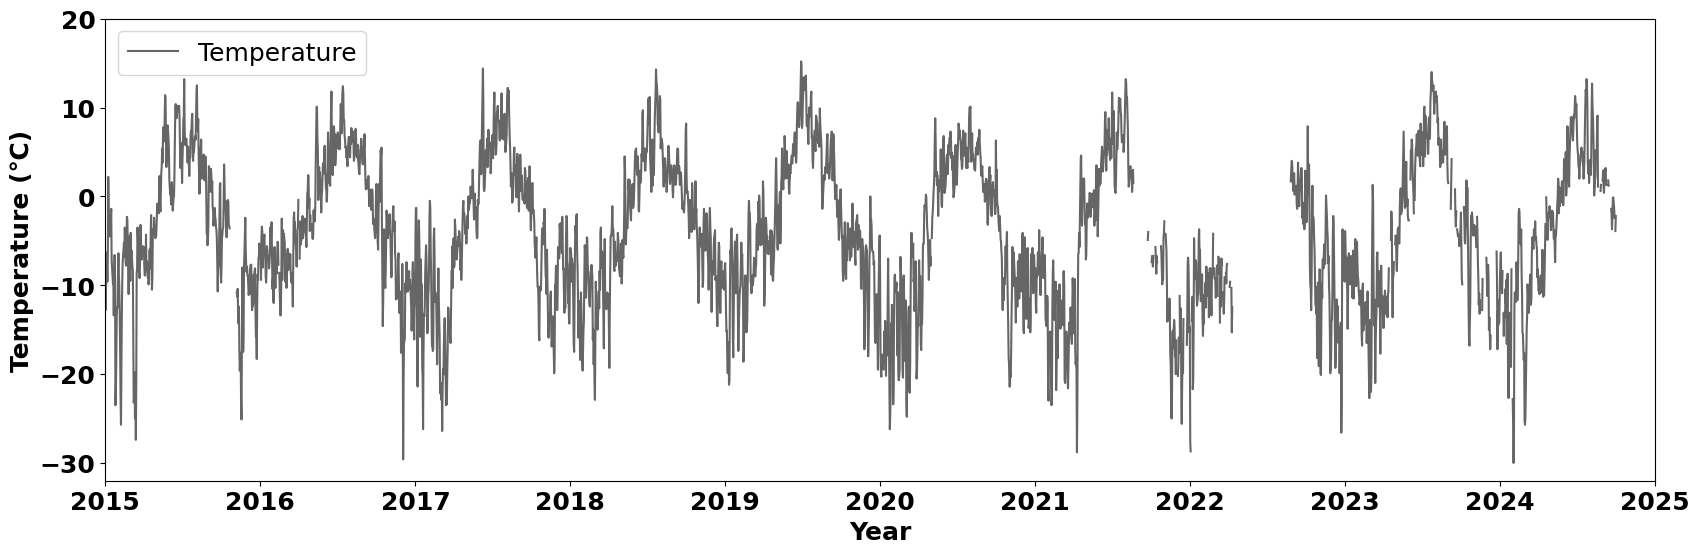

In [5]:
#plot
plt.figure(figsize=(20, 6))
plt.rcParams['font.size'] = 18
plt.plot(weather_df['time'], weather_df['temperature'], label='Temperature', color='#666666')
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Temperature (℃)', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlim(datetime(2015, 1, 1), datetime(2025, 1, 1))
plt.ylim(-32,20)
plt.legend()
plt.show()

## fill aws data gaps with ERA5 data (optional)

In [6]:
#get rid of aws data where ERA5 will be entered
mask = (weather_df['time'] < era_startdate) | (weather_df['time'] > era_enddate)
weather_df = weather_df[mask]
#print(weather_df)

#read in ERA5 temperature data to fill in gaps
era5_path = era5_path + era5_filename
era_data = pd.read_csv(era5_path)
era_data = era_data.drop(columns=['Unnamed: 0'])
#print(era_data)

#make sure time column is in datetime format
#pull time column out and make into a series then convert to datetime format
time_column = era_data['time']
time_column = pd.to_datetime(time_column, yearfirst=True, format='mixed')
era_data['time'] = time_column
    
print(era_data)

         time  temperature
0  2021-08-21     2.596242
1  2021-08-22     2.821910
2  2021-08-23     5.872976
3  2021-08-24     5.513377
4  2021-08-25     5.091248
..        ...          ...
70 2021-10-30    -9.161244
71 2021-10-31    -5.256175
72 2021-11-01    -5.306671
73 2021-11-02    -4.163564
74 2021-11-03    -4.335897

[75 rows x 2 columns]


In [7]:
#combine ERA5 temp data and AWS temp data
weather_df = pd.concat([weather_df, era_data])
weather_df = weather_df.sort_values(by='time')
weather_df = weather_df.reset_index(drop=True)

print(weather_df)

           time  temperature
0    2012-04-20         -2.0
1    2012-04-21         -4.3
2    2012-04-22         -3.8
3    2012-04-23         -3.3
4    2012-04-24         -2.9
...         ...          ...
4542 2024-09-26         -1.3
4543 2024-09-27         -2.4
4544 2024-09-28          NaN
4545 2024-09-29         -3.9
4546 2024-09-30         -2.2

[4547 rows x 2 columns]


In [8]:
#path to ERA5 temperature data
era5_path = '/Users/lindsaysummers/Documents/Research/ERA5/Gulkana/'
era5_filename = 'daily_temp_2022.csv'
era_startdate = '2022-01-31'
era_enddate = '2022-08-26'

#get rid of aws data where ERA5 will be entered
mask = (weather_df['time'] < era_startdate) | (weather_df['time'] > era_enddate)
weather_df = weather_df[mask]
#print(weather_df)

#read in ERA5 temperature data to fill in gaps
era5_path = era5_path + era5_filename
era_data = pd.read_csv(era5_path)
era_data = era_data.drop(columns=['Unnamed: 0'])
#print(era_data)

#make sure time column is in datetime format
#pull time column out and make into a series then convert to datetime format
time_column = era_data['time']
time_column = pd.to_datetime(time_column, yearfirst=True, format='mixed')
era_data['time'] = time_column
    
print(era_data)

          time  temperature
0   2022-01-31   -21.541811
1   2022-02-01   -20.732811
2   2022-02-02   -19.904311
3   2022-02-03   -22.289902
4   2022-02-04   -18.085917
..         ...          ...
203 2022-08-22     7.481908
204 2022-08-23     6.466747
205 2022-08-24     4.896591
206 2022-08-25     3.653828
207 2022-08-26     3.102972

[208 rows x 2 columns]


In [9]:
#combine ERA5 temp data and AWS temp data
weather_df = pd.concat([weather_df, era_data])
weather_df = weather_df.sort_values(by='time')
weather_df = weather_df.reset_index(drop=True)

print(weather_df)

           time  temperature
0    2012-04-20         -2.0
1    2012-04-21         -4.3
2    2012-04-22         -3.8
3    2012-04-23         -3.3
4    2012-04-24         -2.9
...         ...          ...
4542 2024-09-26         -1.3
4543 2024-09-27         -2.4
4544 2024-09-28          NaN
4545 2024-09-29         -3.9
4546 2024-09-30         -2.2

[4547 rows x 2 columns]


## create temperature dataframes for each year

In [10]:
weather_df = weather_df[(weather_df['time'] >= start_date) & (weather_df['time'] <= end_date)]
years =  weather_df['time'].dt.year.unique()
yearly_dataframes = {}
for year in years:
    yearly_dataframes[year] = weather_df[weather_df['time'].dt.year == year].copy()

## import DEMs for each year

In [11]:
DEMs = {}  # dictionary to store DEM file paths

for year in years:
    for file in os.listdir(dem_path):
        if file.endswith(f'{year}.tif'):
            file_path = os.path.join(dem_path, file)
            print(f"Loading {file_path} into DEMs['dem_{year}']")
            DEMs[f'dem_{year}'] = file_path  # store the file path

Loading /Users/lindsaysummers/Documents/Research/DEMs/Gulkana/yearly_100m/Gulkana_DEM_2015.tif into DEMs['dem_2015']
Loading /Users/lindsaysummers/Documents/Research/DEMs/Gulkana/yearly_100m/Gulkana_DEM_2016.tif into DEMs['dem_2016']
Loading /Users/lindsaysummers/Documents/Research/DEMs/Gulkana/yearly_100m/Gulkana_DEM_2017.tif into DEMs['dem_2017']
Loading /Users/lindsaysummers/Documents/Research/DEMs/Gulkana/yearly_100m/Gulkana_DEM_2018.tif into DEMs['dem_2018']
Loading /Users/lindsaysummers/Documents/Research/DEMs/Gulkana/yearly_100m/Gulkana_DEM_2019.tif into DEMs['dem_2019']
Loading /Users/lindsaysummers/Documents/Research/DEMs/Gulkana/yearly_100m/Gulkana_DEM_2020.tif into DEMs['dem_2020']
Loading /Users/lindsaysummers/Documents/Research/DEMs/Gulkana/yearly_100m/Gulkana_DEM_2021.tif into DEMs['dem_2021']
Loading /Users/lindsaysummers/Documents/Research/DEMs/Gulkana/yearly_100m/Gulkana_DEM_2022.tif into DEMs['dem_2022']
Loading /Users/lindsaysummers/Documents/Research/DEMs/Gulkana/ye

## define lon/lat points

In [12]:
#with csv

#import csv containing lat lon points
points_list = pd.read_csv(os.path.join(points_path, points_name))
points_list = points_list.values.tolist()
#print(points_list)

#dictionary to store points
points = {}

for pt in range(len(points_list)):
    points[pt+1] = points_list[pt]
#    print(f'point {pt+1} added to points directory')

In [13]:
#  # read shapefile
# gdf = gpd.read_file(shapefile_path)

# # ensure coordinates are WGS84
# gdf = gdf.to_crs("EPSG:4326")

# points = {}

# for i, row in gdf.iterrows():
#     lon = row.geometry.x
#     lat = row.geometry.y
    
#     pt_id = str(row['Site'])   # use shapefile "site" attribute
    
#     points[pt_id] = [lon, lat]

# print(points)

## extract elevation of each point each year

In [14]:
#change crs to WGS84 and get elevation from lat/lon points
def get_elevation(dem_path, lat, lon):
    with rasterio.open(dem_path) as src:
        if src.crs != 'epsg:4326':
                transformer = Transformer.from_crs("epsg:4326", src.crs, always_xy=True)
                lon, lat = transformer.transform(lon, lat)
        elevation = next(src.sample([(lon, lat)]))[0]
        return elevation

In [15]:
#dictionary to store elevations
elevations = {}

for year, dem_path in DEMs.items():
    elevations[year] = {}
    for pt, coords in points.items():  # pt_num = int, coords = [lon, lat]
        elevation = get_elevation(dem_path, coords[1], coords[0])  # lat=coords[1], lon=coords[0]
#        nodata_value = src.nodata
        # if elevation == nodata_value or np.isnan(elevation):
        #     elevation = np.nan
        if elevation == nodata_value:
            elevation = np.nan
        #elevations[year][f'pt{pt}'] = elevation
        elevations[year][pt] = elevation
#        print(f"Elevation for pt{pt} in {year}: {elevation}")   

## calculate the elevation difference (m) between each point and the AWS for each year

In [16]:
#elevation difference between each point and weather station (m)

#dictionary to store elevation differences
elevation_differences = {}

for year, point in elevations.items():
    elevation_differences[year] = {}
    for pt, elevation in point.items():
        difference = elevation - aws_elevation
        if difference == nodata_value:
            difference = np.nan
        if np.isnan(difference):
            difference = 0.0
        elevation_differences[year][pt] = difference
#        print(f"elevation difference for {pt} in {year}:{difference} m")

## calculate the temperature correction for each point
### lapse rate (°C/m) * elevation difference (m) = correction (°C)

In [17]:
#dictionary to store correction for each point each year
#corrections = {}

# for year, pts_diffs in elevation_differences.items():
#     corrections[year] = {}
#     for pt, elevation_diff in pts_diffs.items():
#         correction = lapse_rate * elevation_diff
#         corrections[year][pt] = correction
# #        print(f"temperature correction for {pt} in {year}: {correction:.2f} °C")

In [18]:
# temperatures = {}
# for dem_key in DEMs.keys():  # e.g., 'dem_2015'
#     year = int(dem_key.replace('dem_', ''))
#     temp_df = yearly_dataframes[year]
#     temperatures[year] = {}
    
#     # Determine which lapse rate to use for each date
#     temp_df['season_lapse_rate'] = np.where(
#         temp_df['time'].dt.month.isin([4, 5, 6, 7, 8, 9]),
#         lapse_rate_summer,
#         lapse_rate_winter
#     )
    
#     # Apply correction for each point
#     for pt, elevation_diff in elevation_differences[dem_key].items():
#         correction = temp_df['season_lapse_rate'] * elevation_diff
#         corrected = temp_df['temperature'] - correction
#         temperatures[year][pt] = corrected

# print(temp_df[['time', 'season_lapse_rate']].head(10))

In [19]:
# temperatures = {}  # initialize dictionary to store corrected temperature data

# for dem_key in DEMs.keys():  # e.g., 'dem_2015'
#     year = int(dem_key.replace('dem_', ''))
#     temp_df = yearly_dataframes[year].copy()
#     temperatures[year] = {}
    
#     # Assign seasonal lapse rates for each date (summer vs winter)
#     temp_df['season'] = np.where(
#         temp_df['time'].dt.month.isin([4, 5, 6, 7, 8, 9]),
#         'summer',
#         'winter'
#     )
    
#     # Loop through each point
#     for pt, elevation_diff in elevation_differences[dem_key].items():
#         if elevation_diff >= 0:
#             # Point is above AWS elevation
#             temp_df['lapse_rate'] = np.where(
#                 temp_df['season'] == 'summer',
#                 lapse_rate_summer_above,
#                 lapse_rate_winter_above
#             )
#         else:
#             # Point is below AWS elevation
#             temp_df['lapse_rate'] = np.where(
#                 temp_df['season'] == 'summer',
#                 lapse_rate_summer_below,
#                 lapse_rate_winter_below
#             )
        
#         # Compute temperature correction
#         correction = temp_df['lapse_rate'] * elevation_diff
#         corrected = temp_df['temperature'] - correction
#         temperatures[year][pt] = corrected


In [20]:
temperatures = {}  # initialize dictionary to store corrected temperature data

for dem_key in DEMs.keys():  # e.g., 'dem_2015'
    year = int(dem_key.replace('dem_', ''))
    temp_df = yearly_dataframes[year].copy()
    temperatures[year] = {}

    # Extract month for each date (1–12)
    temp_df['month'] = temp_df['time'].dt.month

    # Loop through each point
    for pt, elevation_diff in elevation_differences[dem_key].items():
        # Choose above/below lapse rate based on elevation difference
        if elevation_diff >= 0:
            # point is above AWS
            temp_df['lapse_rate'] = temp_df['month'].map(lapse_rates_above)
        else:
            # point is below AWS
            temp_df['lapse_rate'] = temp_df['month'].map(lapse_rates_below)
        
        # Compute correction and adjusted temperature
        correction = temp_df['lapse_rate'] * elevation_diff
        corrected = temp_df['temperature'] - correction
        
        temperatures[year][pt] = corrected

## apply corrections to AWS (+ERA5) temperature data for each point

In [21]:
# #dictionary to store corrected temperatures
# temperatures = {}

# for years in corrections:
#     year = int(years.replace('dem_',''))
#     temp_df = yearly_dataframes[year]
#     temperatures[year] = {}
#     for pt, correction in corrections[years].items():
#         corrected = temp_df['temperature'] - correction
#         temperatures[year][pt] = corrected
# #        print(f"applied temperature correction for {pt} in {year}")

## plot corrected temperatures for each year

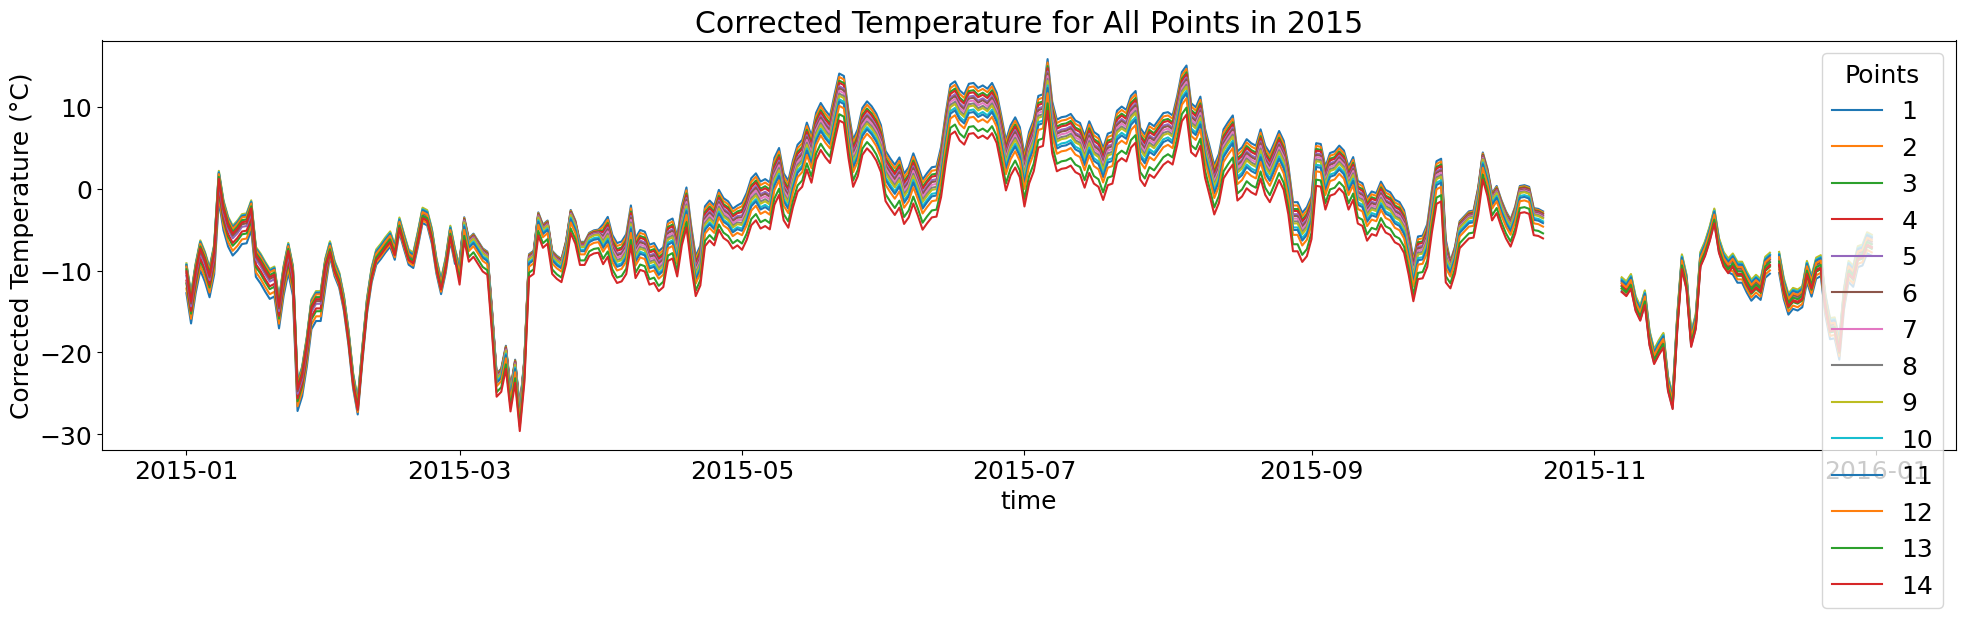

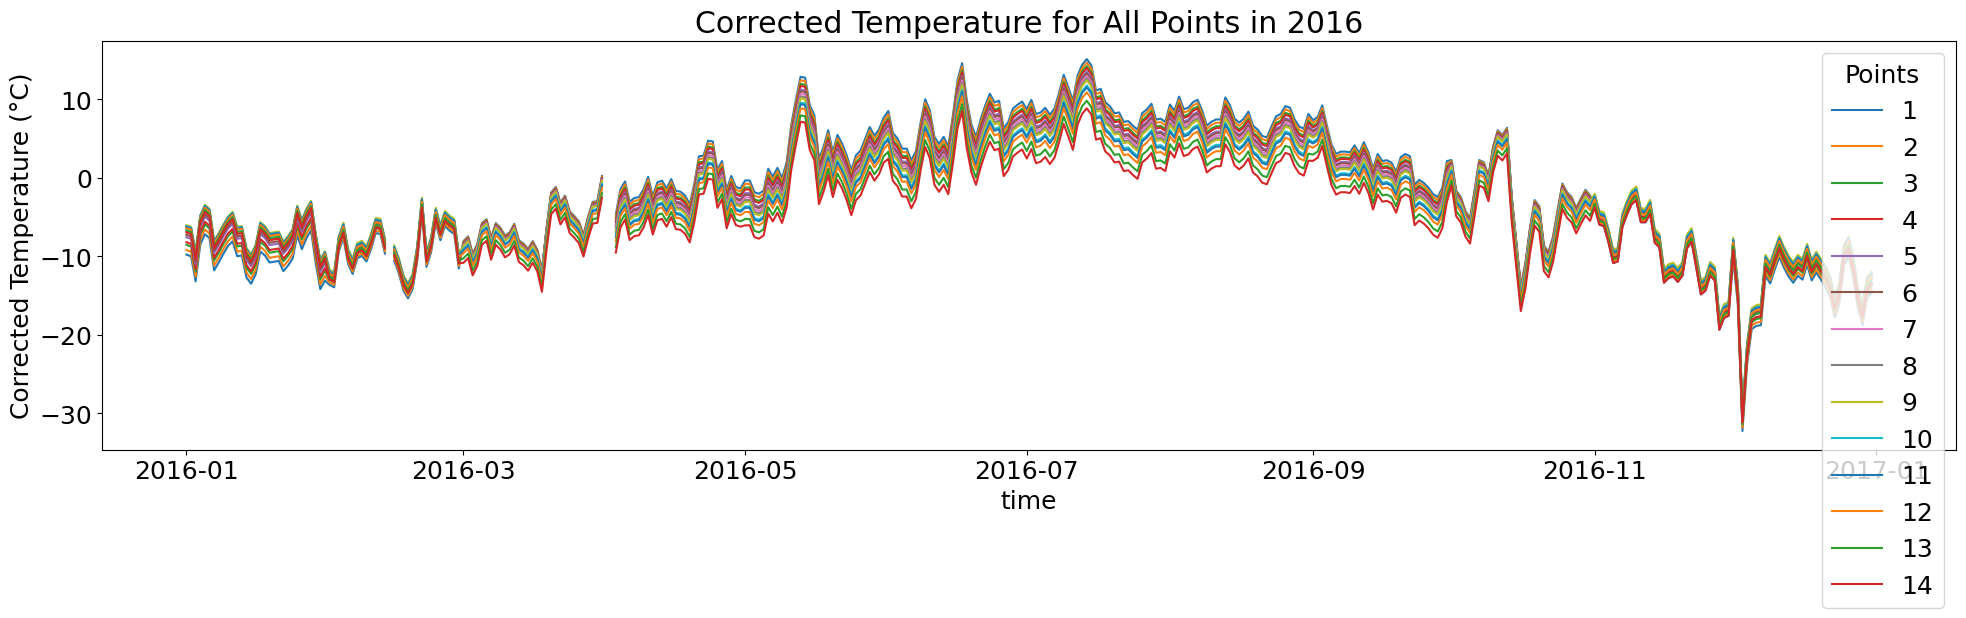

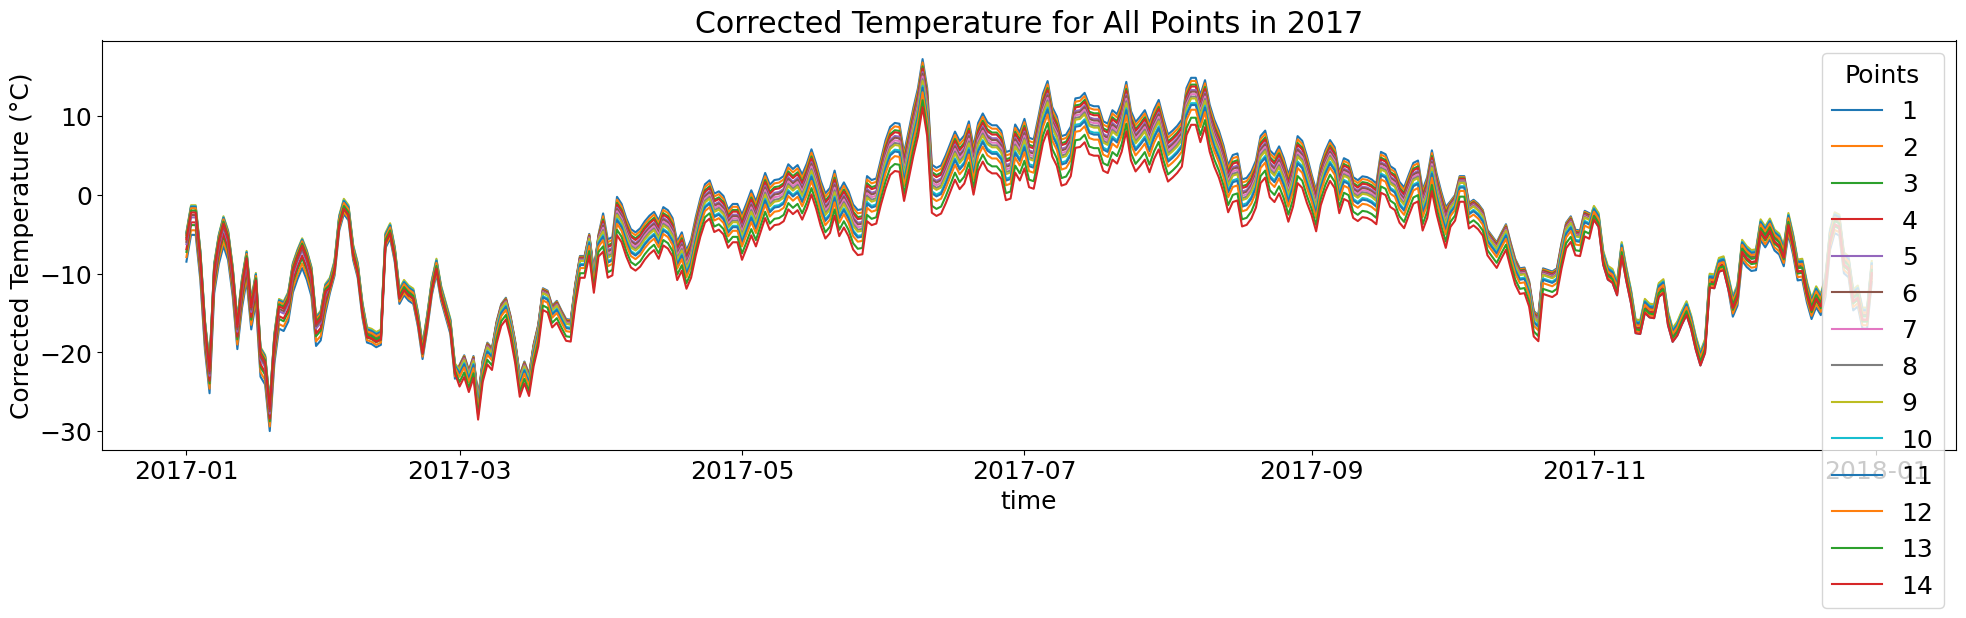

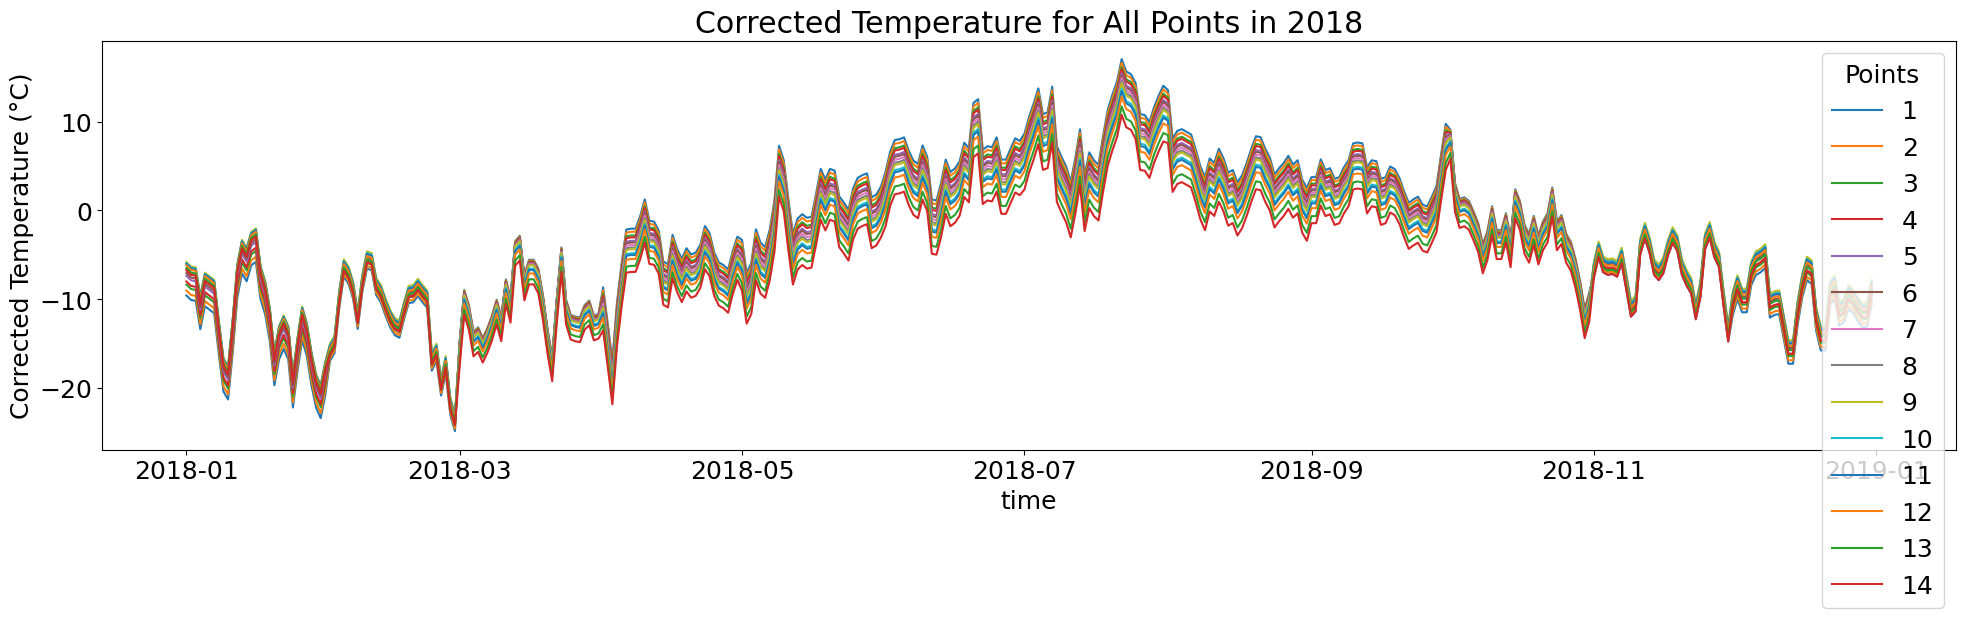

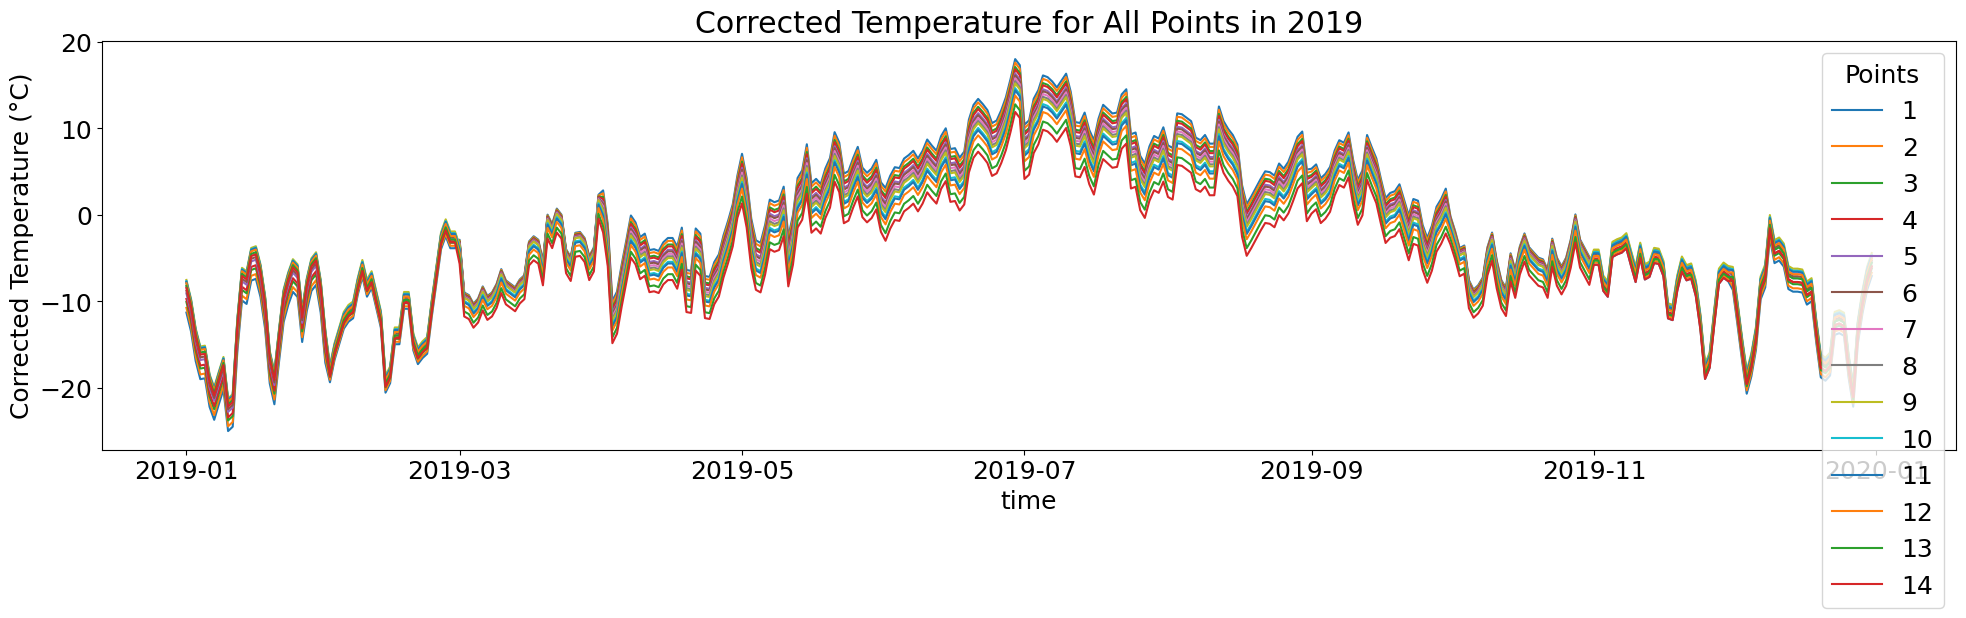

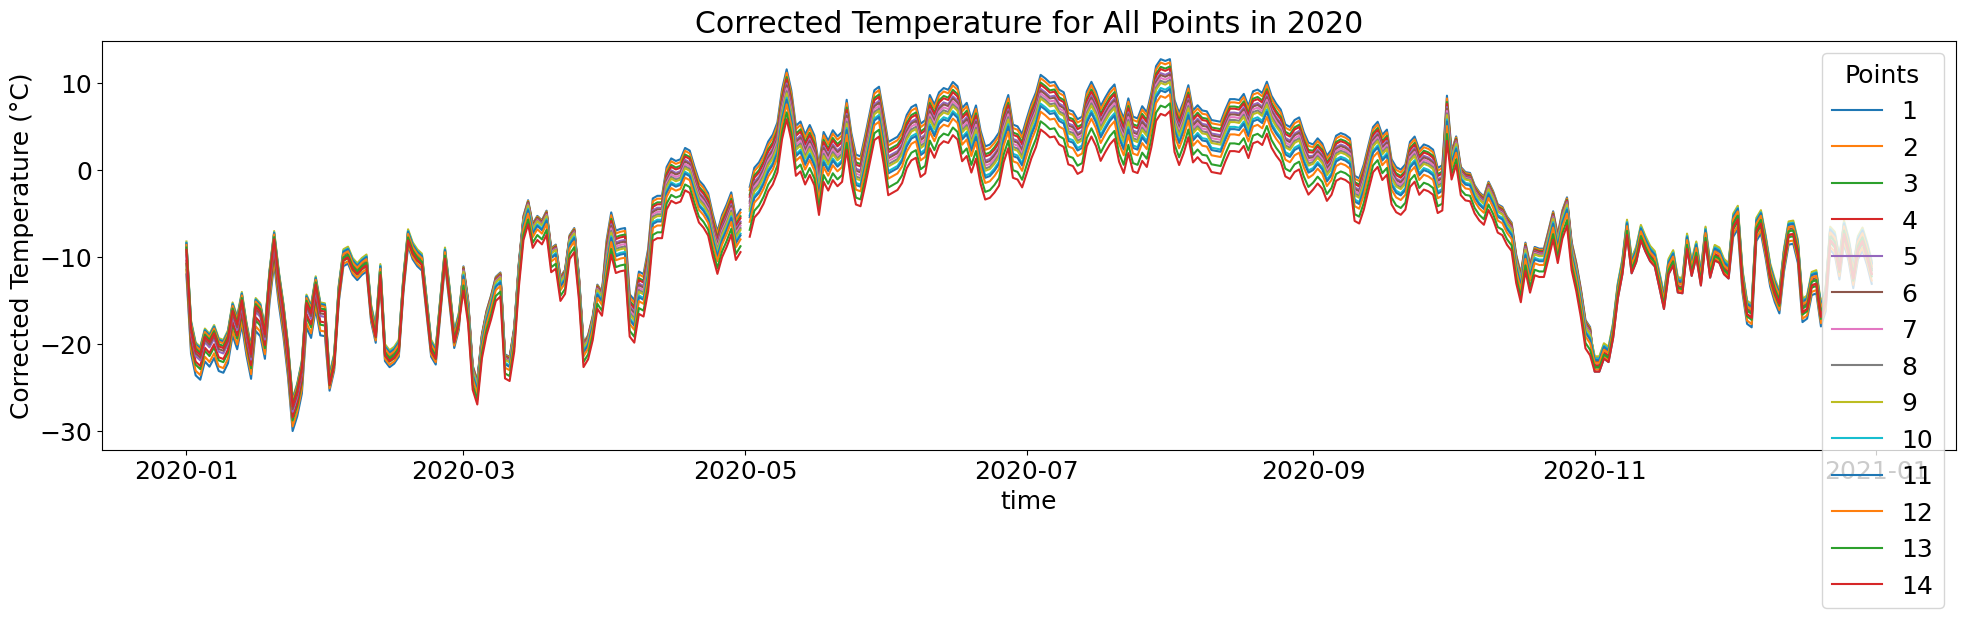

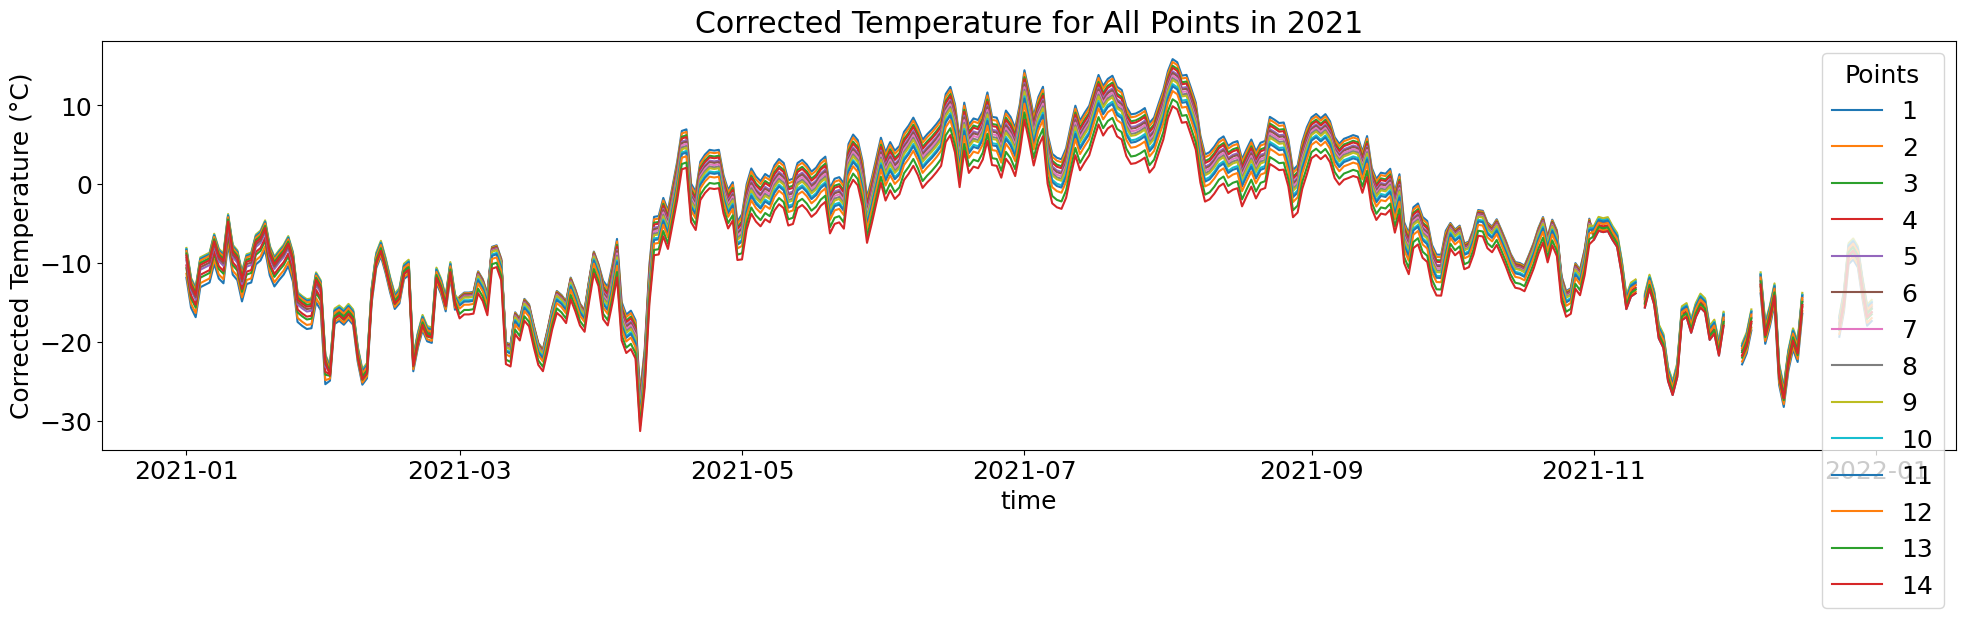

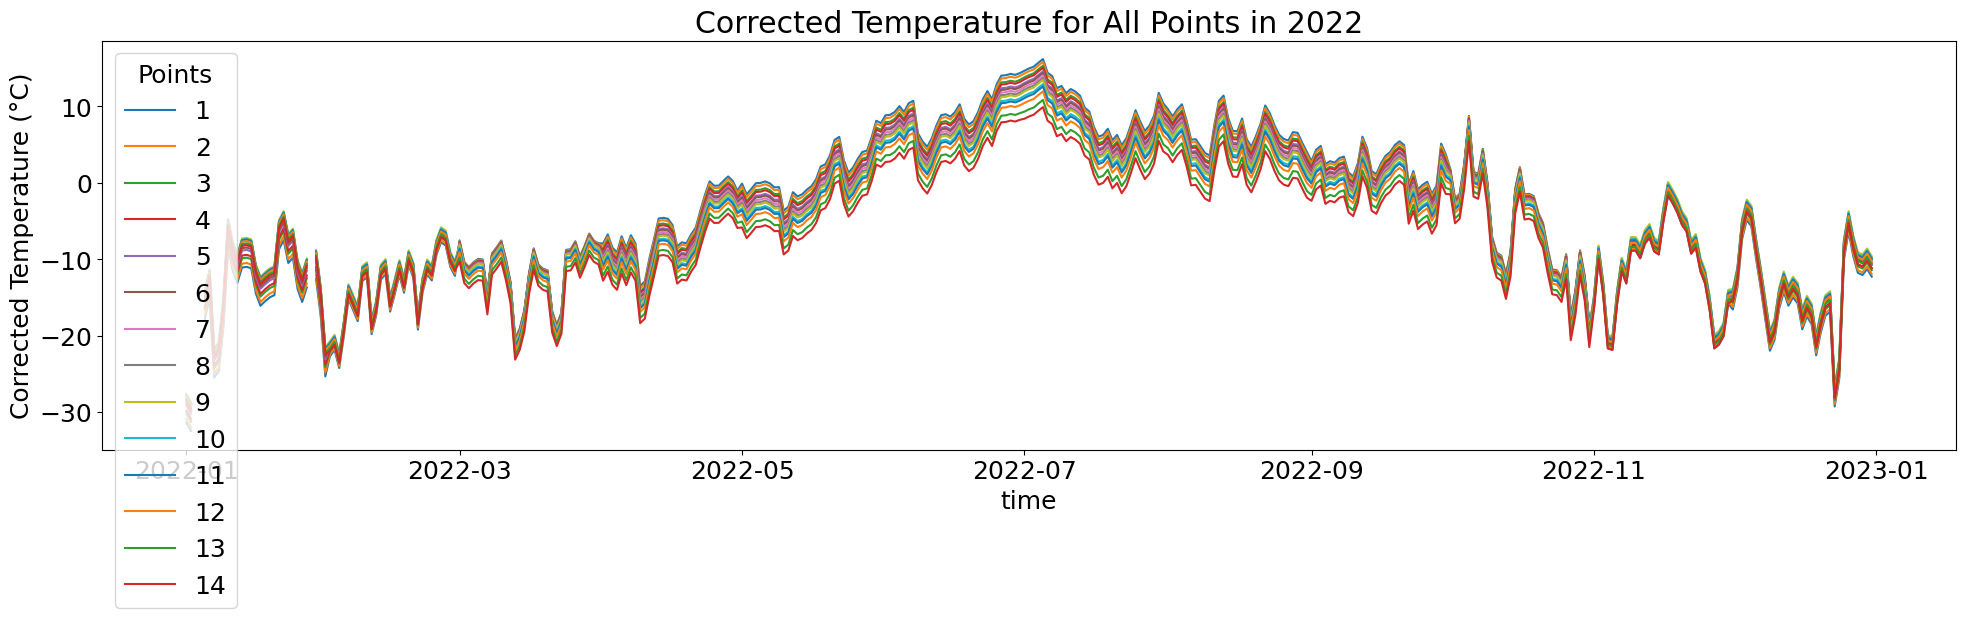

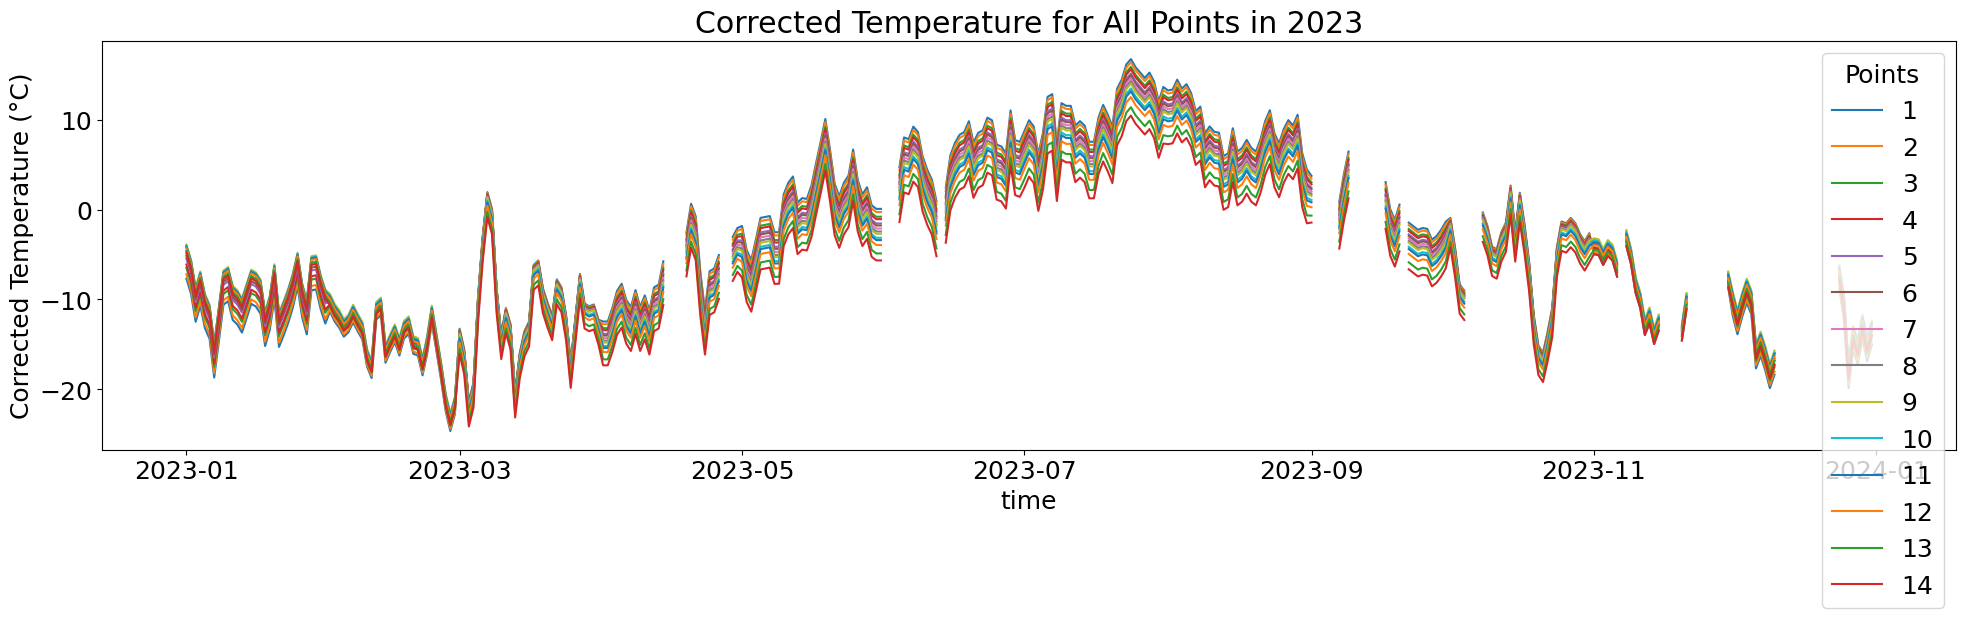

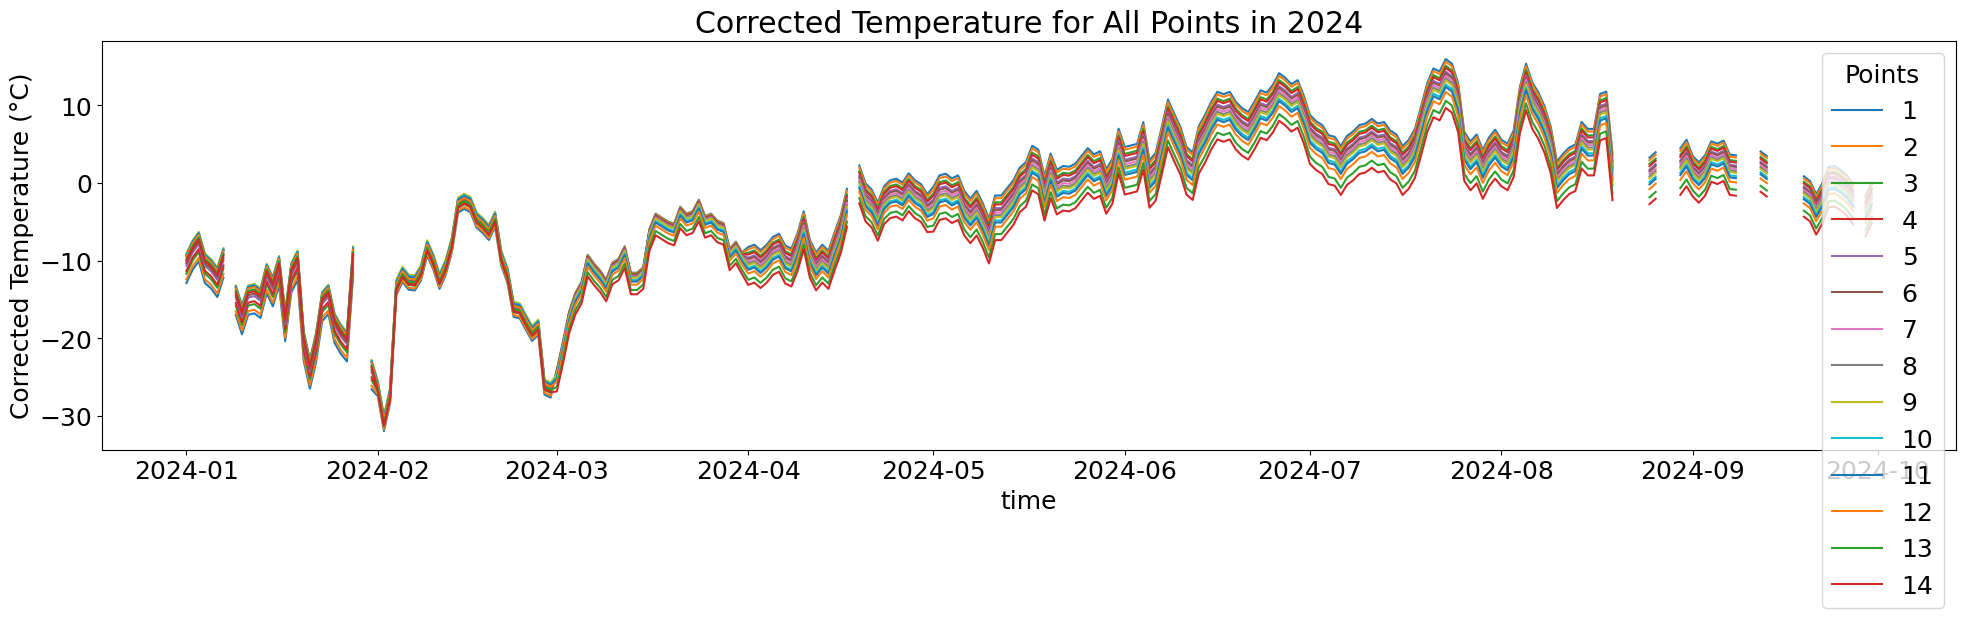

In [22]:
for year, points in temperatures.items():
    temperature_df = yearly_dataframes[year]
    plt.figure(figsize=(20,6))
    for pt, corrected in points.items():
        plt.plot(temperature_df['time'], corrected, label=f'{pt}')

    plt.xlabel('time')
    plt.ylabel('Corrected Temperature (°C)')
    plt.title(f'Corrected Temperature for All Points in {year}')
    plt.legend(title='Points')
    plt.tight_layout()
    plt.show()

## plot corrected temperatures at each point

In [23]:
#get list of all points from the temperatures dictionary
all_points = set()
for years in temperatures.values():
    all_points.update(years.keys())

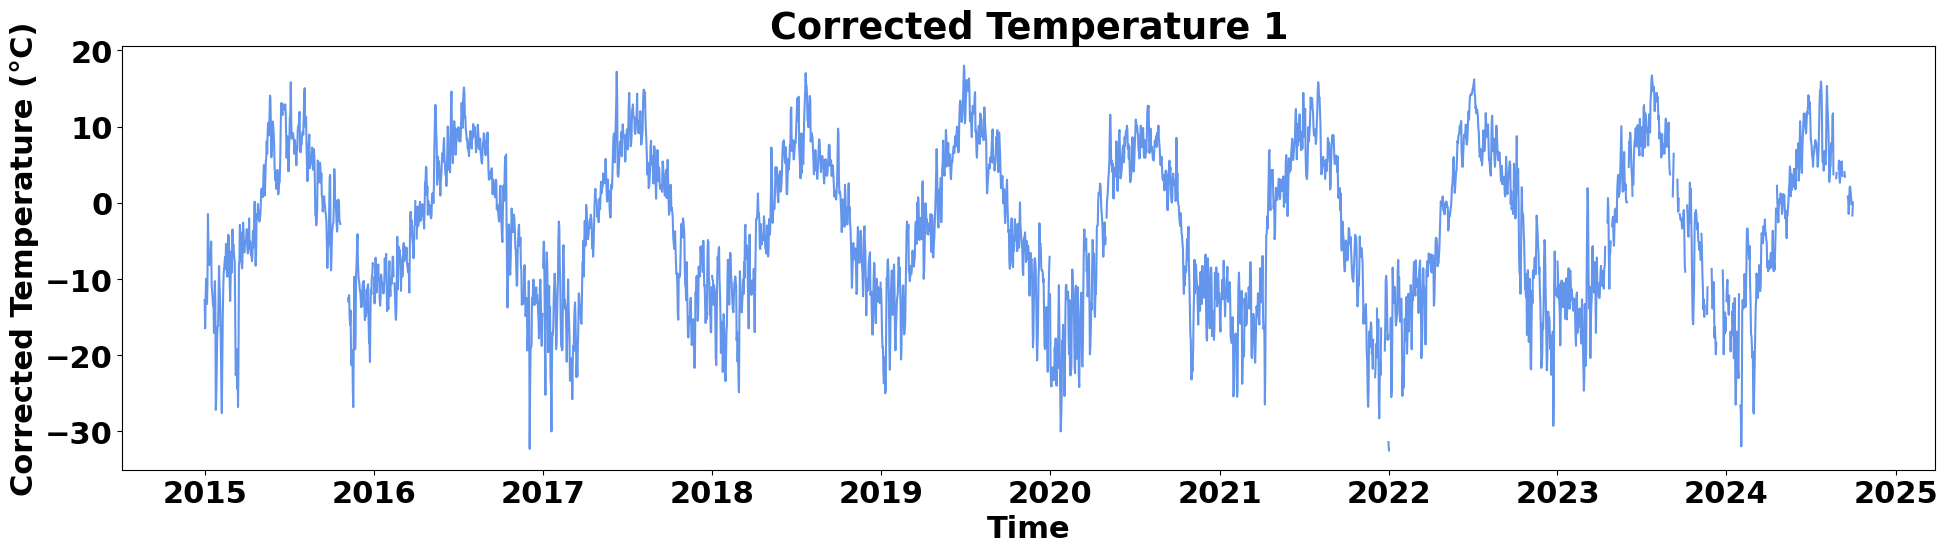

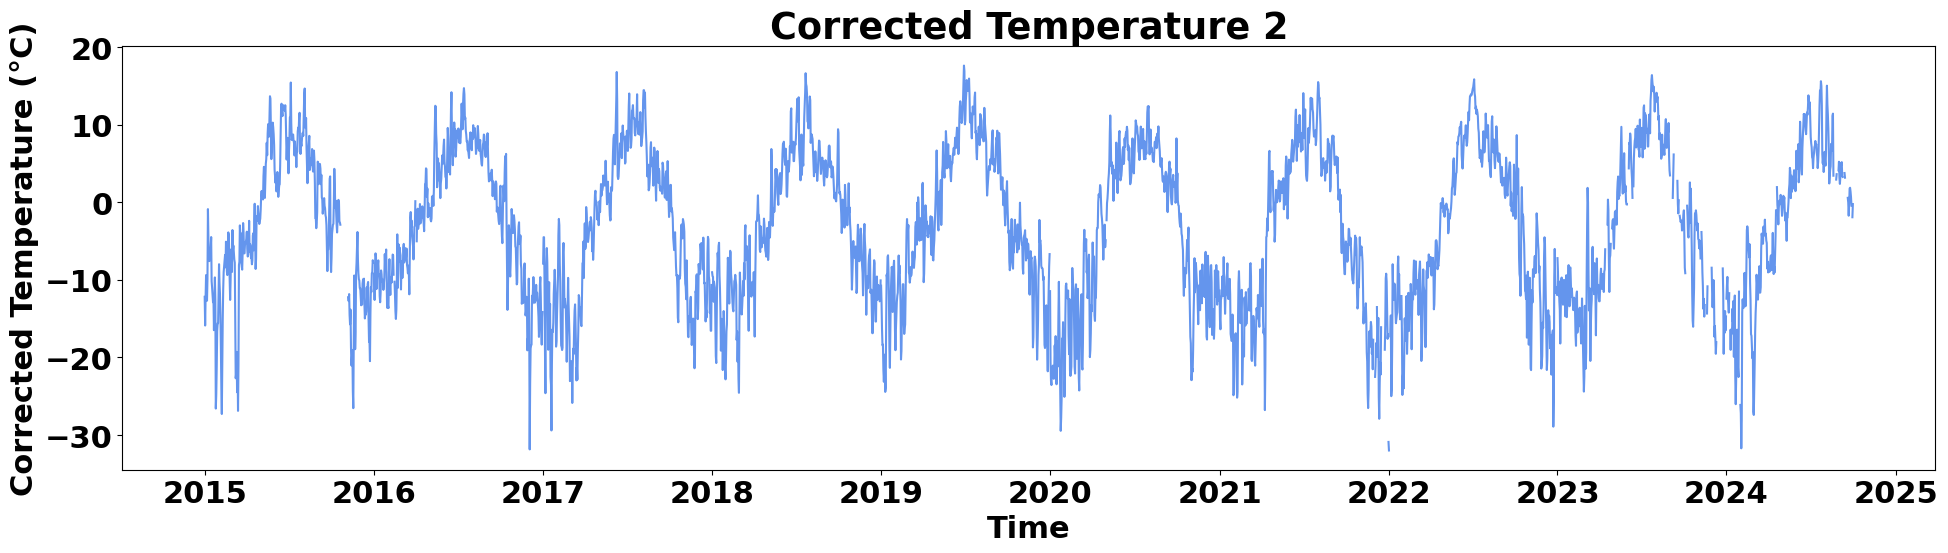

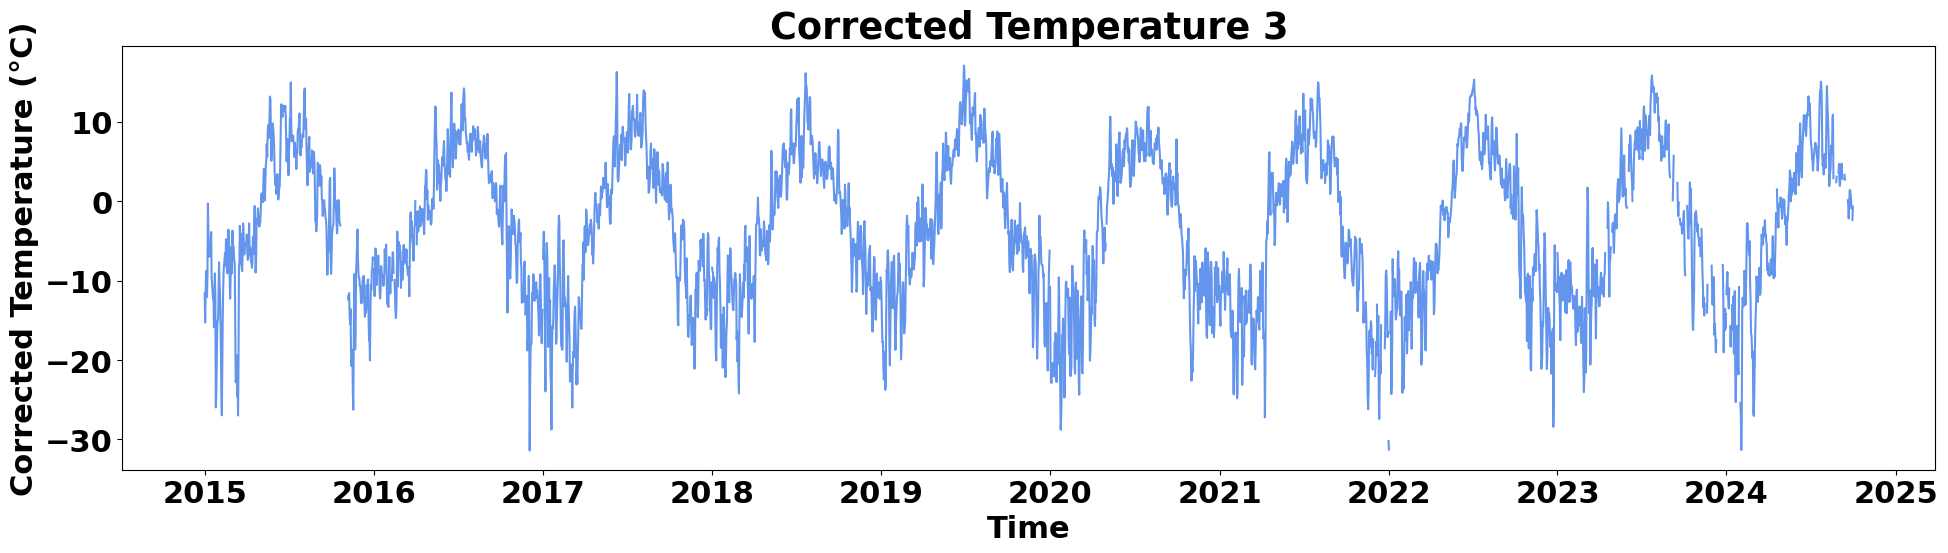

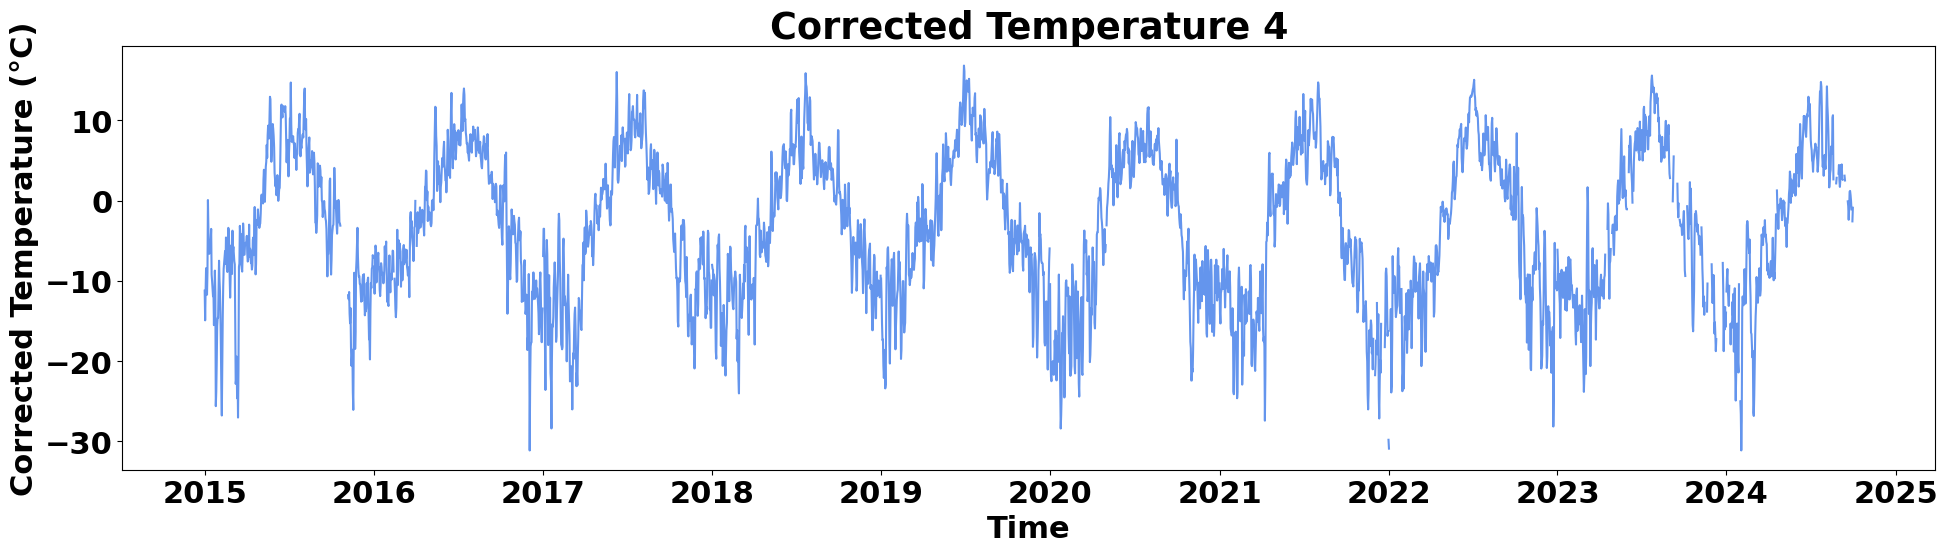

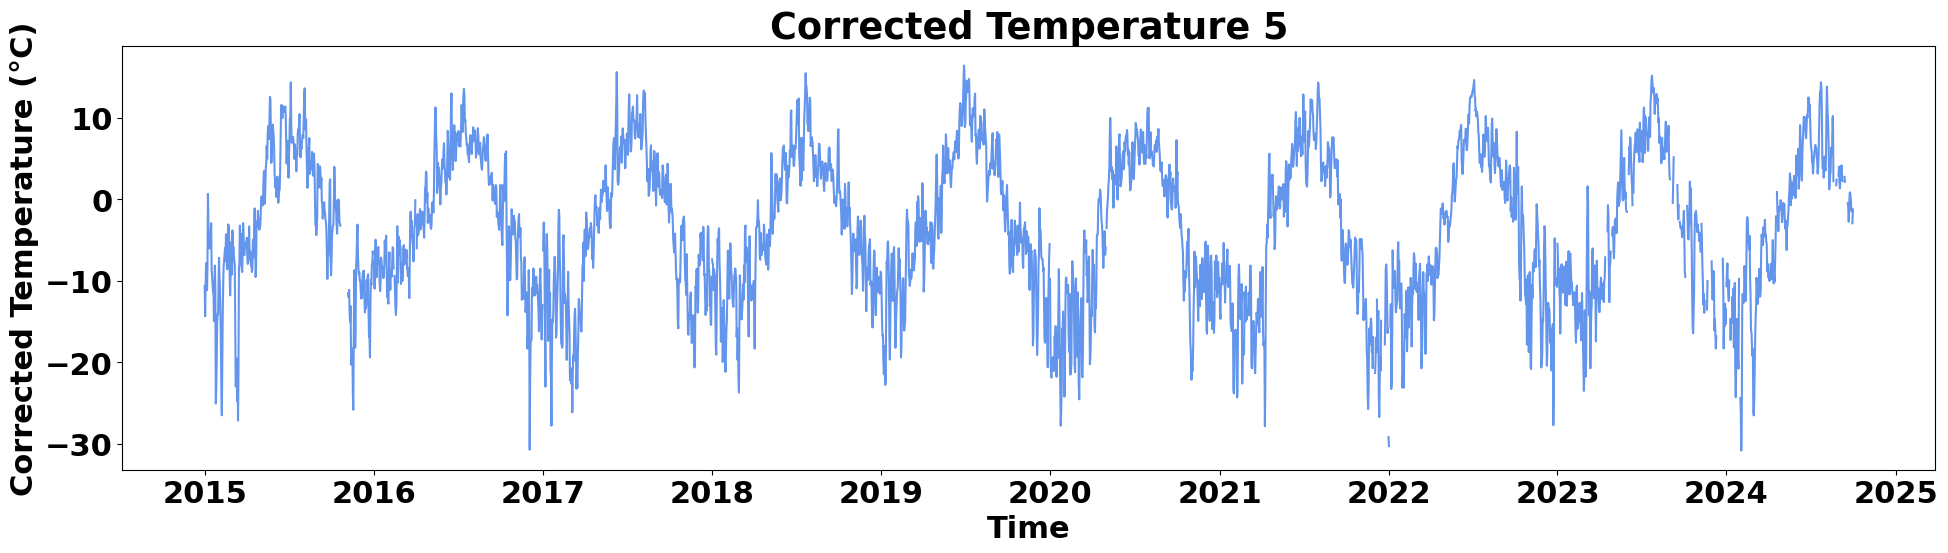

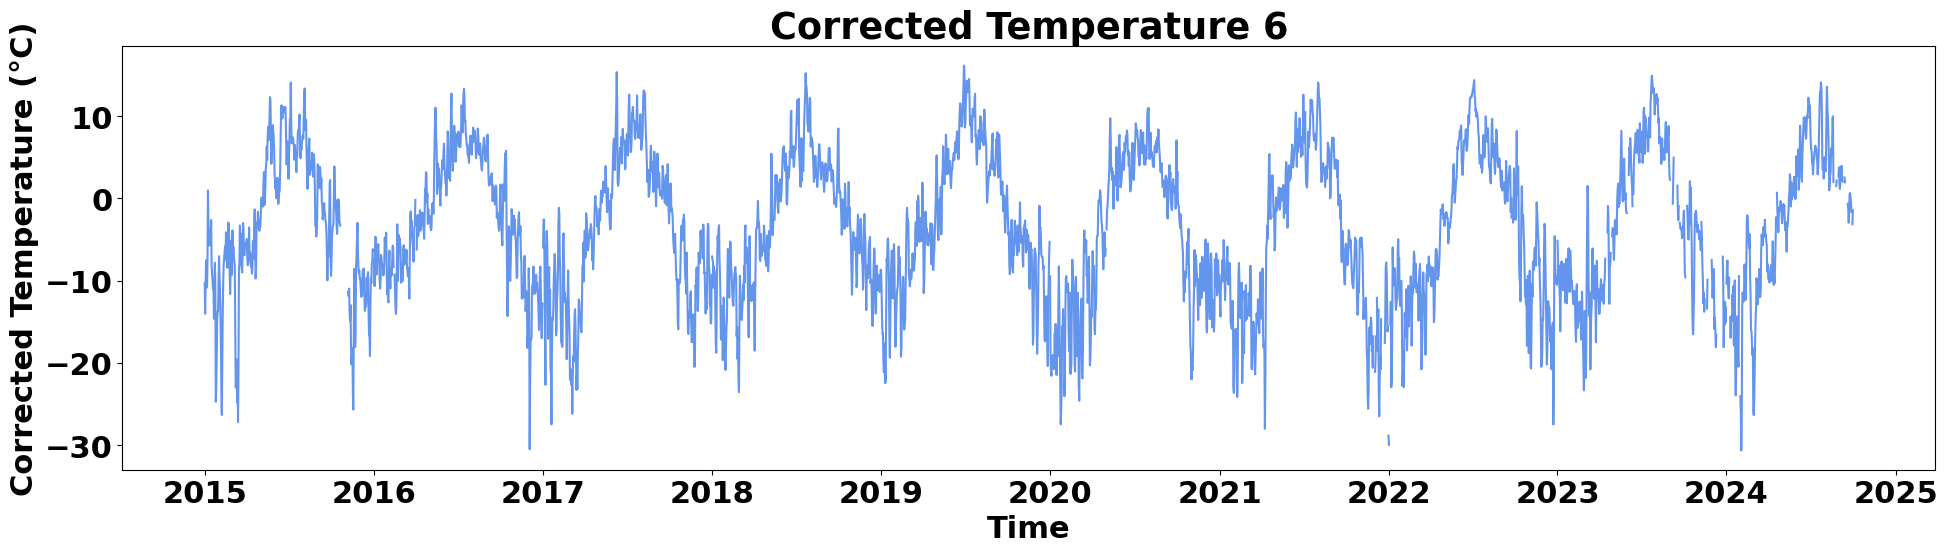

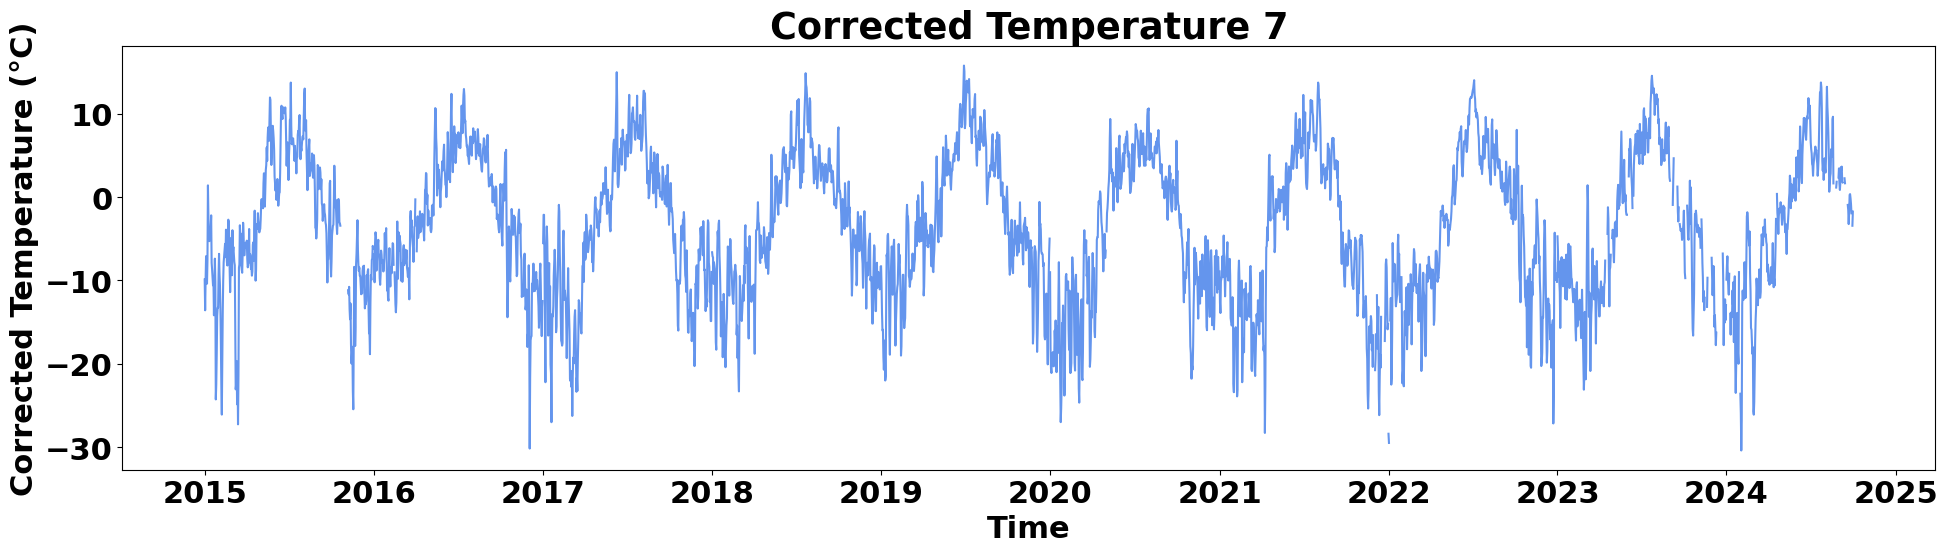

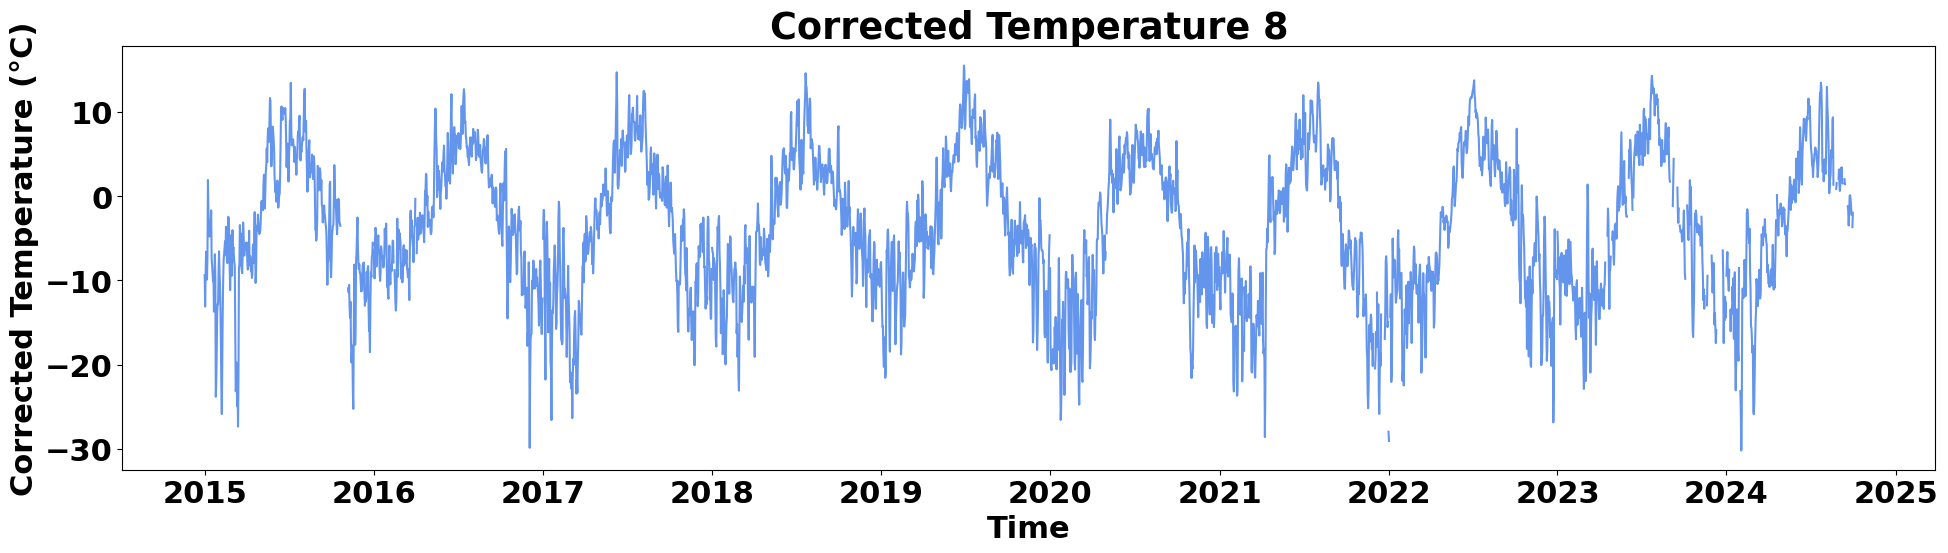

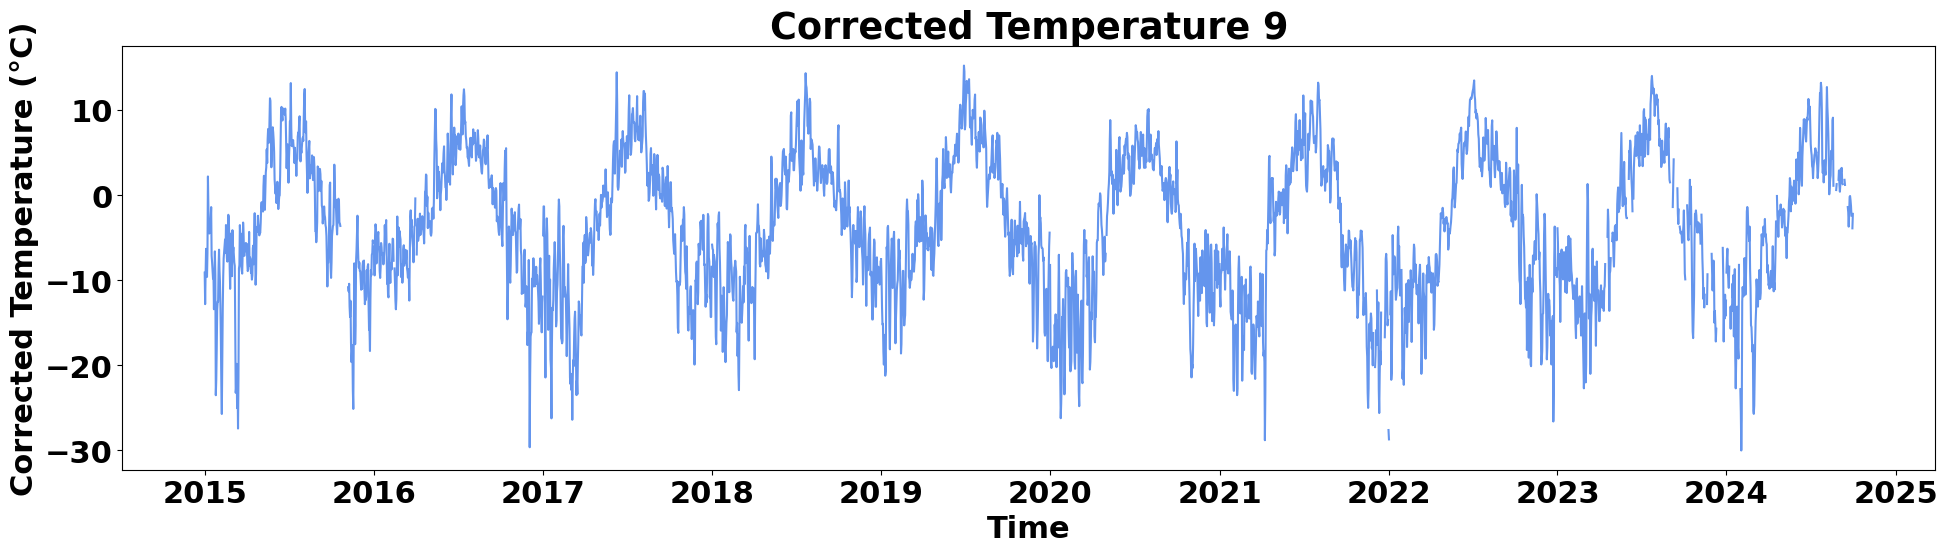

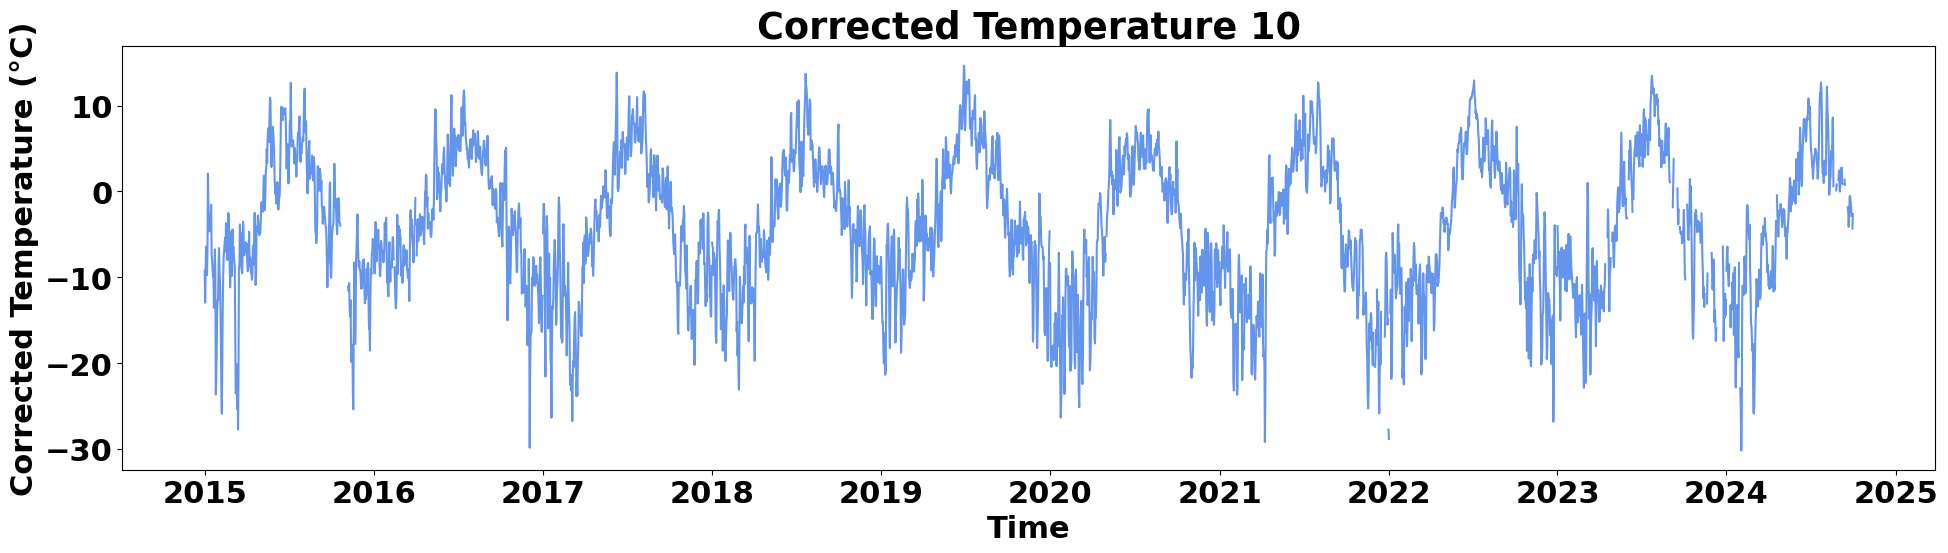

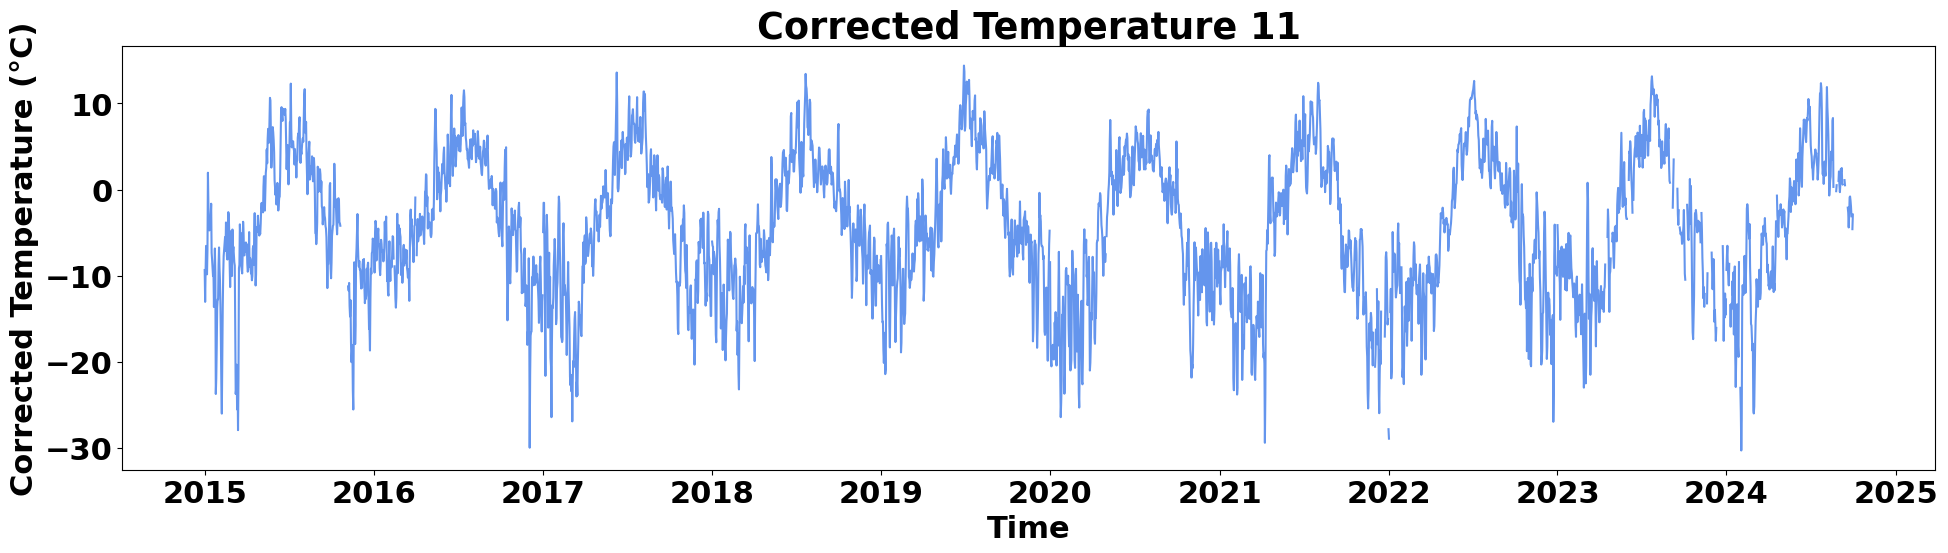

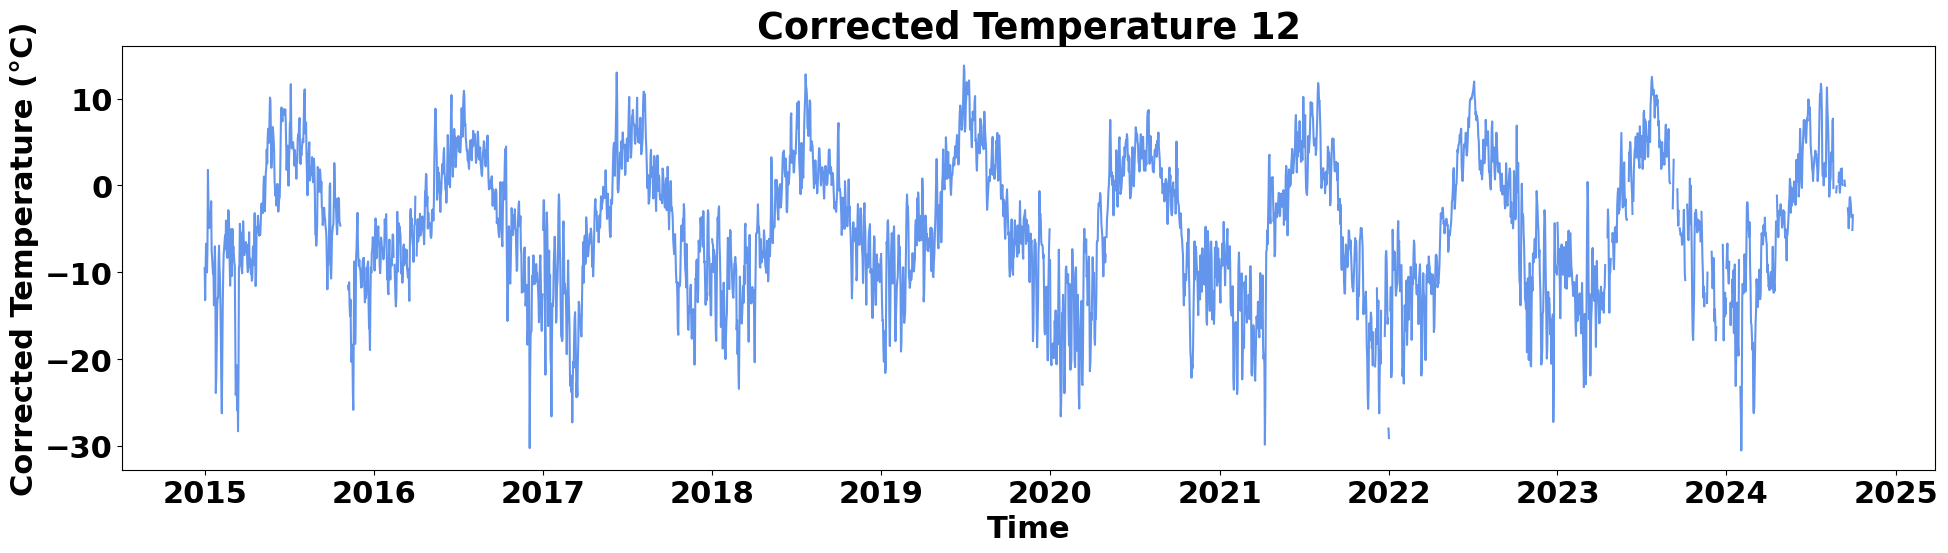

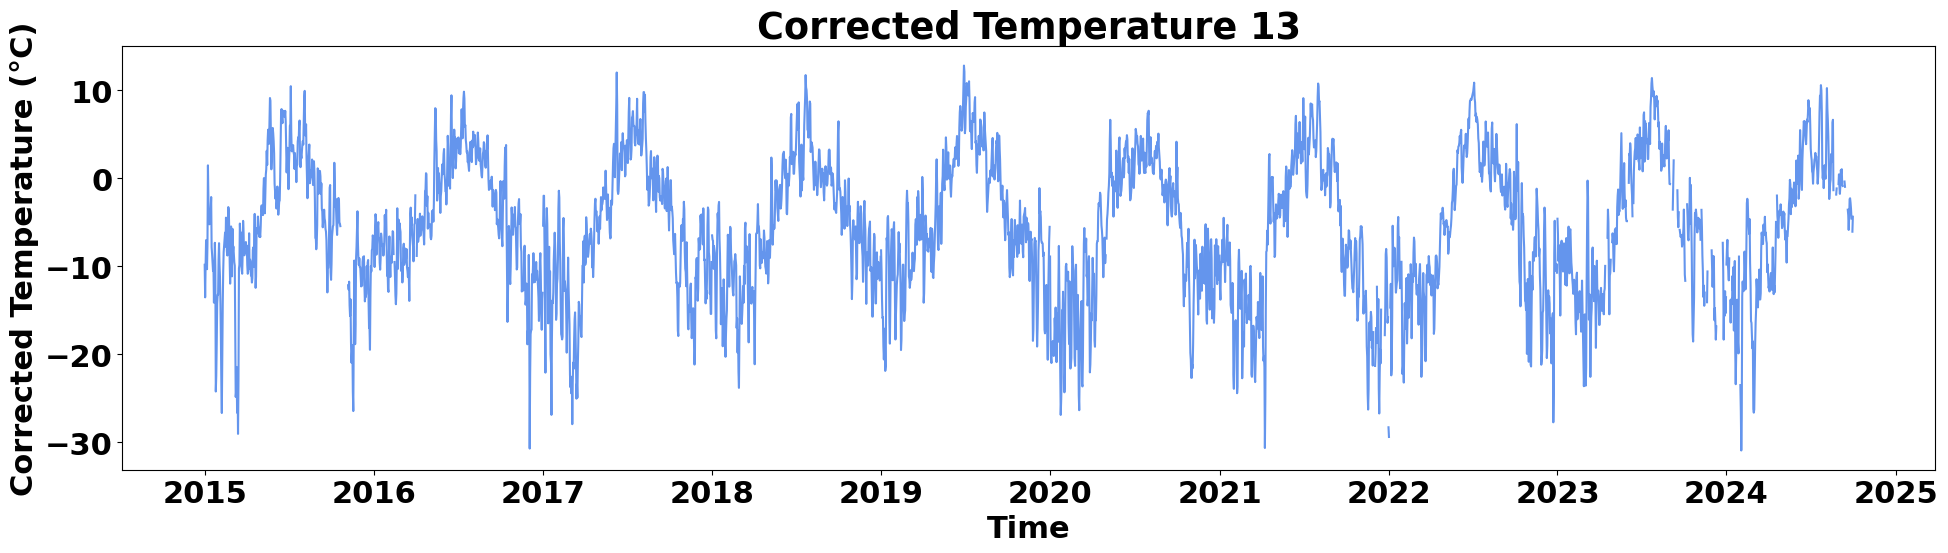

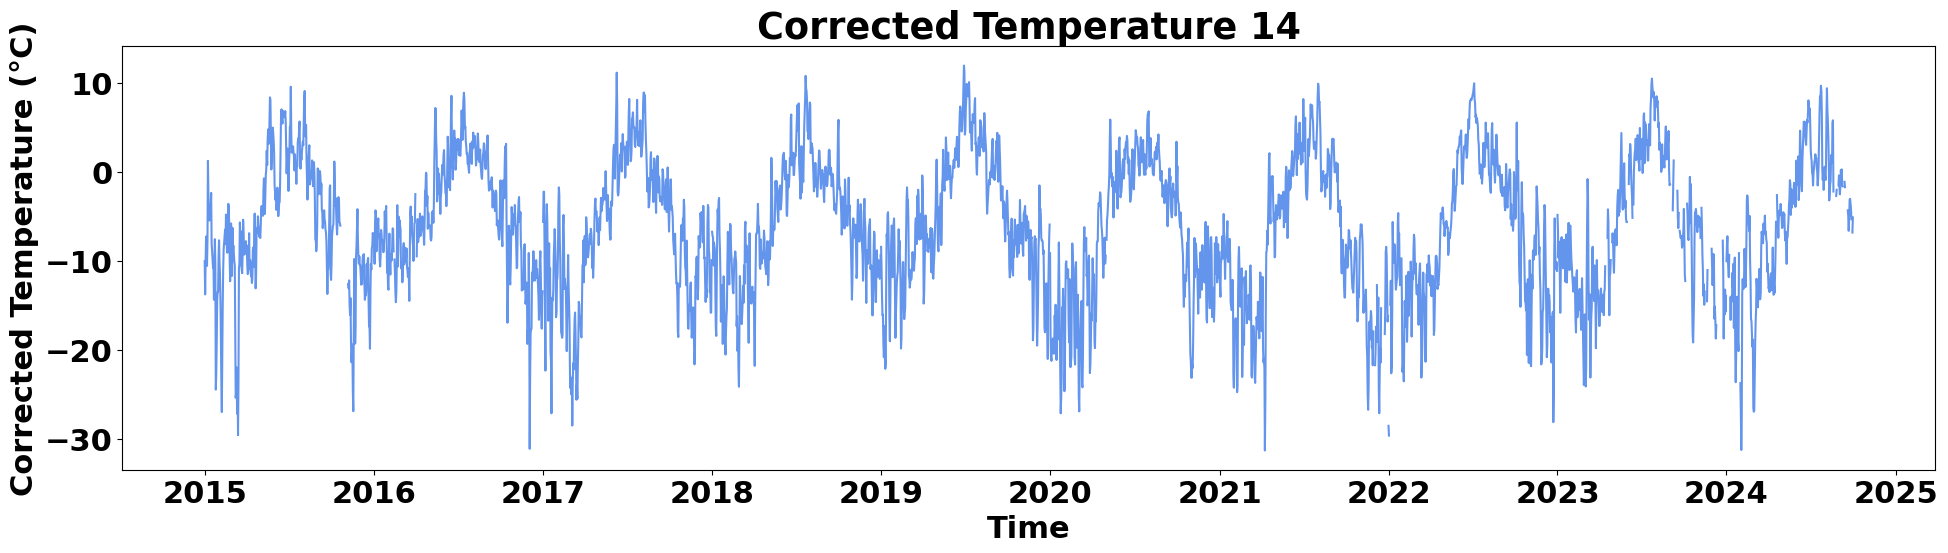

In [24]:
for pt in sorted(all_points):
    plt.figure(figsize=(20, 6))
    plt.rcParams.update({'font.size': 22})
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['font.weight'] = 'bold'
    
    for year, points in temperatures.items():
        temp_df = yearly_dataframes[year]
        
        if pt in points:
            corrected_temp = points[pt]
            plt.plot(temp_df['time'], corrected_temp, color='cornflowerblue')
    
    plt.xlabel('Time')
    plt.ylabel('Corrected Temperature (°C)')
    plt.title(f'Corrected Temperature {pt}')
    #plt.xlim(datetime(2019,10,1), datetime(2020,3,1))
    plt.tight_layout()
    plt.show()

## combine data (continuous record for each point) and export

In [25]:
for pt in sorted(all_points):
    continuous_record = pd.DataFrame()
    years_sorted = sorted(temperatures.keys())
    for year in sorted(years_sorted):
        if pt in temperatures[year]:
            temperature_series = temperatures[year][pt]
            time_series = yearly_dataframes[year]['time']

            df_year_point = pd.DataFrame({'time': time_series, 'corrected_temperature': temperature_series})
            continuous_record = pd.concat([continuous_record, df_year_point], ignore_index=True)
        continuous_record = continuous_record.sort_values(by='time').reset_index(drop=True) #sort by time
        continuous_record.to_csv(out_path + f'corrected_temperatures_pt{pt}.csv')
#        print(f"Exported data for {pt} to CSV.")